# 5.2 Stage 1.5 & Stage 2: Feature Enrichment → Cost Prediction

**Pipeline:** Stage 0 (Feature Engineering) → Stage 1 (2D Classification, 10-class) → **Stage 1.5 (Feature Enrichment)** → **Stage 2 (Cost Prediction)**

**Stage 1.5 rationale:** Stage 1 classifies patients into 10 classes (Y1 cost level × transition direction). Within each class, costs still vary. Stage 1.5 enriches features with:
- **ENGAGEMENT_SCORE**: Utilization pattern (proactive vs. crisis-oriented care)
- **ESCALATION_MAGNITUDE**: Predicted cost bin change magnitude (regression on DELTA_BIN)
- **Raw Rx features**: RX_DENSITY, RX_GAP_RATIO, RX_TRAILING_GAP, RX_REGULARITY (genuinely new information from prescription timelines)

**Stage 2 approach:** Tier-specific XGBoost on log(1+cost). Each tier gets its own model, so Stage 1.5 latent factors drive within-tier differentiation instead of being drowned out by the much larger between-tier cost differences.


## Data Leakage Prevention
- All features use **Year 1 data only**
- Stage 1 tier probabilities generated via **out-of-fold** prediction
- Stage 1.5 latent factors use **cross-validated** predictions
- Train/val/test split is **stratified by panel** (7:2:1)


In [22]:
# SETUP & IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Sklearn imports
from sklearn.model_selection import (
    train_test_split, cross_val_predict, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    LogisticRegression, TweedieRegressor, Ridge
)
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor,
    StackingClassifier, StackingRegressor
)
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, accuracy_score, mean_squared_error, mean_absolute_error,
    r2_score
)

# XGBoost
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Paths
DATA_PATH = Path('../data/processed_v2/model_ready_stage1.parquet')
DATA_PATH_BACKUP = Path('../data/processed_v2/model_ready_v2.parquet')
REPORT_DIR = Path('../reports')
(REPORT_DIR / 'figures').mkdir(parents=True, exist_ok=True)
(REPORT_DIR / 'tables').mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


---
## 1. Load Data from Stage 1

In [23]:
# Try to load Stage 1 output; fallback to base processed data
if DATA_PATH.exists():
    df = pd.read_parquet(DATA_PATH)
    print(f"Loaded Stage 1 output: {DATA_PATH}")
    has_stage1_output = 'LATENT_RISK_SCORE' in df.columns
else:
    df = pd.read_parquet(DATA_PATH_BACKUP)
    print(f"Loaded base processed data: {DATA_PATH_BACKUP}")
    has_stage1_output = False

CLASS_NAMES = {
    0: 'Low_Improve',   1: 'Low_Stable',    2: 'Low_MildRise',  3: 'Low_Jumper',
    4: 'Mid_Improve',   5: 'Mid_Stable',    6: 'Mid_Escalate',
    7: 'High_Improve',  8: 'High_Stable',   9: 'High_Escalate',
}

print(f"\nDataset: {len(df):,} rows, {len(df.columns)} columns")
print(f"Stage 1 Latent Factors Available: {has_stage1_output}")

# Show columns
print(f"\nColumns: {list(df.columns)}")

Loaded Stage 1 output: ../data/processed_v2/model_ready_stage1.parquet

Dataset: 60,602 rows, 54 columns
Stage 1 Latent Factors Available: True

Columns: ['DUPERSID', 'PANEL', 'START_YEAR', 'AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1', 'MNHLTH_RD1', 'RTHLTH_RD1', 'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'CHRONIC_COUNT', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1', 'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CNT_RX_Y1', 'CNT_UNIQUE_DRUGS', 'TOTAL_RX_COST_Y1', 'POLYPHARMACY_FLAG', 'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 'HAS_RESPIRATORY_RX', 'HAS_GI_RX', 'RATIO_ER_OFFICE', 'COST_Y1_ADJ', 'COST_Y2_ADJ', 'LOG_COST_Y2', 'Y1_BIN', 'Y2_BIN', 'DELTA_BIN', 'Y1_LEVEL', 'RISK_TIER', 'IS_JUMPER', 'IS_STABLE_LOW', 'CARE_CLUSTER', 'DBSCAN_CLUSTER', 'PROB_LOW_IMPROVE', 'PROB_LOW_STABLE', 'PROB_LOW_MILDRISE', 'PROB_LOW_JUMPER', 'PROB_MID_IMPROVE', 'PROB_MID_STABLE', 'PROB_MID_ESCALATE', 'PROB_HIGH_IMPROVE', 'PROB_HIGH_STABLE', 'PROB_HIGH_ESCALATE', 'LAT

---
# STAGE 1.5: Feature Enrichment

Stage 1.5 adds clinically meaningful constructs and raw Rx features to the original feature set. Unlike the previous version which built 5 redundant latent factors, this streamlined version keeps only features that add genuinely new information.

**What's kept:**
- 1.5B: ENGAGEMENT_SCORE (direct calculation, no model)
- 1.5C: ESCALATION_MAGNITUDE (regression on DELTA_BIN — new, replaces PROB_UNDIAGNOSED)
- 1.5E: Raw Rx timeline features (RX_DENSITY, RX_GAP_RATIO, RX_TRAILING_GAP, RX_REGULARITY)

**What's removed and why:**
- PROB_CRISIS_MODE: r=-0.99 with ENGAGEMENT_SCORE (perfectly redundant)
- ESCALATION_SCORE: r=0.73 with Stage 1 (its components already in original features)
- HAZARD_DISCONTINUE: r=0.91 with LATENT_RISK_SCORE (same target as Stage 1, raw Rx features are more useful)

**Why not just use original features directly in Stage 2?** Because raw features (e.g., UTIL_ER_Y1, UTIL_OB_Y1) are individual measurements, while latent factors combine them into clinically meaningful *constructs* (e.g., "this patient's utilization pattern suggests reactive crisis-mode care"). This gives the Stage 2 model higher-level signals to work with.

| Factor | What it captures | Method | Input variables |
|--------|-----------------|--------|----------------|
| ENGAGEMENT_SCORE | Proactive vs crisis care pattern | Direct formula | UTIL_ER, UTIL_OB, UTIL_IP |
| PROB_UNDIAGNOSED | Hidden riser risk | RF classifier (IS_JUMPER target) | CNT_ILL_DEFINED, conditions, utilization |
| ESCALATION_SCORE | Comorbidity-driven cost escalation | Composite index | CHRONIC_COUNT, IP, polypharmacy |
| HAZARD_DISCONTINUE | Medication adherence risk | GB classifier | Rx timeline features |

**Removed:** Stage 1.5A (PROB_MH_DECLINE) — r=0.01 with cost; feature importance showed only MNHLTH_RD1 mattered, making it a noisy copy of an original feature rather than a meaningful latent construct.


---
## Stage 1.5B: Healthcare Engagement Score

**What:** Composite score measuring whether a patient's Y1 care pattern is proactive (regular office visits) or reactive (ER/IP-dependent).

**Formula:** `ENGAGEMENT_SCORE = Norm(Office) - Norm(ER_ratio) - 0.5 × Norm(IP)`, range [-1, 1]

**PROB_CRISIS_MODE:** Sigmoid transform of the engagement score. Note: negative correlation with Y2 cost is expected — high office-visit patients typically have chronic conditions generating sustained high costs, while ER-dependent patients may have acute events that resolve.


In [24]:
# STAGE 1.5B: Healthcare Engagement Score (Direct Calculation)
#
# Methodology: No predict_proba needed - directly calculate from Y1 data
# 
# ENGAGEMENT_SCORE = Composite metric, range [-1, 1]:
#   +1 = Very proactive (high office visits, low ER)
#   -1 = Crisis-oriented (high ER/IP, low office)
#

print("STAGE 1.5B: Healthcare Engagement Score (Direct Calculation)")

# Calculate Engagement Score directly from Y1 utilization data
if all(c in df.columns for c in ['UTIL_ER_Y1', 'UTIL_OB_Y1', 'UTIL_IP_Y1']):
    
    # --- Normalization function ---
    def normalize_0_1(series):
        """Min-max normalize to [0, 1]"""
        min_val, max_val = series.min(), series.max()
        if max_val == min_val:
            return series * 0
        return (series - min_val) / (max_val - min_val)
    
    # --- Calculate components ---
    
    # 1. ER dependency: ER / (ER + Office + 1), high=bad
    total_visits = df['UTIL_ER_Y1'] + df['UTIL_OB_Y1'] + 1
    er_dependency = df['UTIL_ER_Y1'] / total_visits
    er_score = normalize_0_1(er_dependency)
    
    # 2. IP intensity: hospitalization=high risk, high=bad
    ip_score = normalize_0_1(df['UTIL_IP_Y1'].clip(upper=5))  # cap at 5
    
    # 3. Office engagement: moderate=good, but too many may indicate issues
    ob_optimal = df['UTIL_OB_Y1'].clip(upper=df['UTIL_OB_Y1'].quantile(0.9))
    ob_score = normalize_0_1(ob_optimal)
    
    # --- Calculate Engagement Score ---
    # Formula: Office(+) - ER_dependency(-) - IP_intensity(-)
    raw_score = ob_score - er_score - ip_score * 0.5
    
    # Normalize to [-1, 1]
    df['ENGAGEMENT_SCORE'] = raw_score / max(raw_score.abs().max(), 0.001)
    
    # --- Classification (for visualization only) ---
    def classify_engagement(score):
        if score > 0.3:
            return 'Proactive'
        elif score < -0.3:
            return 'Crisis-Mode'
        else:
            return 'Reactive'
    
    df['ENGAGEMENT_TYPE'] = df['ENGAGEMENT_SCORE'].apply(classify_engagement)
    
    # --- Output ---
    print(f"\n=== Engagement Score (Direct Calculation) ===")
    print(f"Formula: Score = Normalized(Office) - Normalized(ER_ratio) - 0.5×Normalized(IP)")
    print(f"\nStatistics:")
    print(f"  Mean:   {df['ENGAGEMENT_SCORE'].mean():.3f}")
    print(f"  Std:    {df['ENGAGEMENT_SCORE'].std():.3f}")
    print(f"  Range:  [{df['ENGAGEMENT_SCORE'].min():.3f}, {df['ENGAGEMENT_SCORE'].max():.3f}]")
    
    print(f"\nEngagement Type Distribution:")
    for t in ['Proactive', 'Reactive', 'Crisis-Mode']:
        n = (df['ENGAGEMENT_TYPE'] == t).sum()
        print(f"  {t}: {n:,} ({n/len(df)*100:.1f}%)")
    
else:
    print("⚠ Utilization columns not available. Setting ENGAGEMENT_SCORE = 0")
    df['ENGAGEMENT_SCORE'] = 0.0
    df['ENGAGEMENT_TYPE'] = 'Unknown'

STAGE 1.5B: Healthcare Engagement Score (Direct Calculation)

=== Engagement Score (Direct Calculation) ===
Formula: Score = Normalized(Office) - Normalized(ER_ratio) - 0.5×Normalized(IP)

Statistics:
  Mean:   0.151
  Std:    0.236
  Range:  [-1.000, 0.667]

Engagement Type Distribution:
  Proactive: 12,960 (21.4%)
  Reactive: 45,857 (75.7%)
  Crisis-Mode: 1,785 (2.9%)


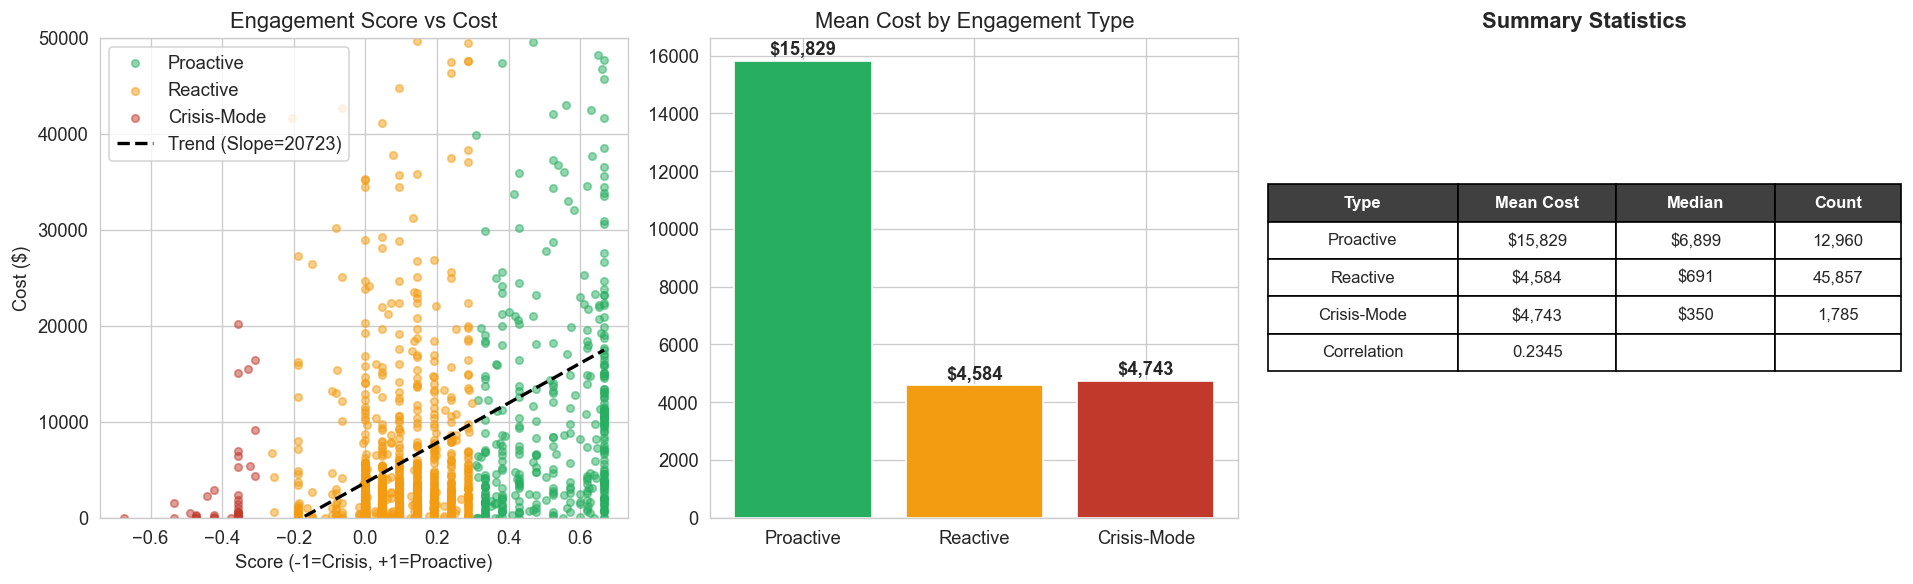

In [25]:
# VISUALIZATION: Stage 1.5B - Healthcare Engagement Score

if 'ENGAGEMENT_SCORE' in df.columns:
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # --- Panel 1: Scatter Plot ---
    ax1 = axes[0]
    sample = df.sample(min(2000, len(df)), random_state=42)
    
    # Color mapping
    colors = {'Proactive': '#27ae60', 'Reactive': '#f39c12', 'Crisis-Mode': '#c0392b'}
    for label, color in colors.items():
        subset = sample[sample['ENGAGEMENT_TYPE'] == label]
        ax1.scatter(subset['ENGAGEMENT_SCORE'], subset['COST_Y2_ADJ'], 
                   c=color, alpha=0.5, s=20, label=label)
                   
    # Trend line
    z = np.polyfit(sample['ENGAGEMENT_SCORE'], sample['COST_Y2_ADJ'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(sample['ENGAGEMENT_SCORE'].min(), sample['ENGAGEMENT_SCORE'].max(), 100)
    ax1.plot(x_range, p(x_range), 'k--', linewidth=2, label=f'Trend (Slope={z[0]:.0f})')
    
    ax1.set_title('Engagement Score vs Cost')
    ax1.set_xlabel('Score (-1=Crisis, +1=Proactive)')
    ax1.set_ylabel('Cost ($)')
    ax1.legend()
    ax1.set_ylim(0, 50000)
    
    # --- Panel 2: Mean Cost by Type ---
    ax2 = axes[1]
    stats = df.groupby('ENGAGEMENT_TYPE')['COST_Y2_ADJ'].agg(['mean', 'median', 'count']).reset_index()
    # Reorder
    order = ['Proactive', 'Reactive', 'Crisis-Mode']
    stats['ENGAGEMENT_TYPE'] = pd.Categorical(stats['ENGAGEMENT_TYPE'], categories=order, ordered=True)
    stats = stats.sort_values('ENGAGEMENT_TYPE')
    
    bars = ax2.bar(stats['ENGAGEMENT_TYPE'], stats['mean'], color=[colors[x] for x in stats['ENGAGEMENT_TYPE']])
    
    for bar, val in zip(bars, stats['mean']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
                 f'${val:,.0f}', ha='center', fontweight='bold')
                 
    ax2.set_title('Mean Cost by Engagement Type')
    
    # --- Panel 3: Real Table ---
    ax3 = axes[2]
    ax3.axis('off')
    
    corr = df['ENGAGEMENT_SCORE'].corr(df['COST_Y2_ADJ'])
    
    table_data = [['Type', 'Mean Cost', 'Median', 'Count']]
    for _, row in stats.iterrows():
        table_data.append([
            row['ENGAGEMENT_TYPE'], 
            f"${row['mean']:,.0f}", 
            f"${row['median']:,.0f}", 
            f"{row['count']:,}"
        ])
        
    table_data.append(['Correlation', f'{corr:.4f}', '', ''])
    
    table = ax3.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.3, 0.25, 0.25, 0.2])
    table.scale(1.2, 1.8)
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    
    for i in range(4):
        table[(0, i)].set_facecolor('#404040')
        table[(0, i)].set_text_props(color='white', fontweight='bold')

    ax3.set_title('Summary Statistics', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

### Interpretation: Healthcare Engagement Score

- **Proactive patients** (score > 0.3): Regular office visits, low ER usage. Often managing chronic conditions — associated with higher total costs due to ongoing medication and procedures.
- **Crisis-mode patients** (score < -0.3): High ER/IP, low office visits. Acute care pattern — may have lower total cost if events are isolated.
- **Reactive patients** (middle): Mixed utilization pattern.

**Value for Stage 2:** This score adds information beyond raw utilization counts by encoding the *pattern* of care. Two patients with similar total visit counts but different ER/office ratios will have different engagement scores.


---
## Stage 1.5C: Escalation Magnitude Prediction

**What:** Predicted magnitude of cost bin change (DELTA_BIN) for each patient. A continuous score indicating how many bins the model expects a patient to move up or down.

**Previous approach:** Binary classification predicting IS_JUMPER (yes/no). Problem: negative correlation with cost because most non-jumpers have low PROB_UNDIAGNOSED, making the score anti-correlated with expenditure.

**New approach:** Regression on DELTA_BIN using GradientBoosting. **Method:** RandomForest with balanced class weights, 5-fold cross-validated predictions.

**Key features:** CNT_ILL_DEFINED (symptom codes without clear diagnosis), utilization patterns, chronic disease flags.

**Note:** Negative correlation with average Y2 cost is expected — most patients with this profile remain low-cost; only a small fraction actually jump. The score identifies *risk of jumping*, not expected cost level.


In [26]:
# STAGE 1.5C: Escalation Magnitude Prediction (Regression on DELTA_BIN)
#
# Previous approach: Binary classification (IS_JUMPER yes/no) → PROB_UNDIAGNOSED
# Problem: Negative correlation with cost, nearly all patients got near-zero probability
#
# New approach: Regression predicting DELTA_BIN (continuous cost bin change)
# This produces ESCALATION_MAGNITUDE — a score indicating how many bins
# the model expects a patient to jump, based on clinical signals.
#

print("STAGE 1.5C: Escalation Magnitude Prediction")

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_predict, KFold

if 'DELTA_BIN' in df.columns:
    print(f"\nTarget: DELTA_BIN (cost bin change Y2 - Y1)")
    print(f"  Mean: {df['DELTA_BIN'].mean():.3f}, Std: {df['DELTA_BIN'].std():.3f}")
    print(f"  Range: [{df['DELTA_BIN'].min()}, {df['DELTA_BIN'].max()}]")
    
    escalation_features = [
        'AGE_Y1', 'SEX',
        'CNT_ILL_DEFINED',
        'CNT_TOTAL_CONDITIONS',
        'UTIL_OB_Y1', 'UTIL_ER_Y1', 'UTIL_IP_Y1',
        'MNHLTH_RD1', 'RTHLTH_RD1',
        'CHRONIC_COUNT',
        'CNT_RX_Y1',
        'COST_Y1_ADJ',
        'ENGAGEMENT_SCORE'
    ]
    escalation_features = [f for f in escalation_features if f in df.columns]
    print(f"\nFeatures used ({len(escalation_features)}): {escalation_features}")
    
    X_esc = df[escalation_features].fillna(0)
    y_esc = df['DELTA_BIN']
    
    esc_model = GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=42
    )
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    esc_preds = cross_val_predict(esc_model, X_esc, y_esc, cv=cv)
    df['ESCALATION_MAGNITUDE'] = esc_preds
    
    esc_model.fit(X_esc, y_esc)
    
    r_delta = np.corrcoef(esc_preds, y_esc)[0, 1]
    r_cost = np.corrcoef(df['ESCALATION_MAGNITUDE'], df['COST_Y2_ADJ'])[0, 1]
    
    print(f"\nLatent Factor Created: ESCALATION_MAGNITUDE")
    print(f"  Mean: {df['ESCALATION_MAGNITUDE'].mean():.3f}")
    print(f"  Std:  {df['ESCALATION_MAGNITUDE'].std():.3f}")
    print(f"  Correlation with actual DELTA_BIN: r = {r_delta:.3f}")
    print(f"  Correlation with COST_Y2_ADJ: r = {r_cost:.3f}")
    
    esc_importance = pd.DataFrame({
        'Feature': escalation_features,
        'Importance': esc_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"\nTop Features for Escalation Magnitude Prediction:")
    print(esc_importance.head(6).to_string(index=False))

else:
    print("WARNING: DELTA_BIN not available. Setting ESCALATION_MAGNITUDE = 0")
    df['ESCALATION_MAGNITUDE'] = 0.0

STAGE 1.5C: Escalation Magnitude Prediction

Target: DELTA_BIN (cost bin change Y2 - Y1)
  Mean: -0.015, Std: 1.139
  Range: [-4, 4]

Features used (13): ['AGE_Y1', 'SEX', 'CNT_ILL_DEFINED', 'CNT_TOTAL_CONDITIONS', 'UTIL_OB_Y1', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'MNHLTH_RD1', 'RTHLTH_RD1', 'CHRONIC_COUNT', 'CNT_RX_Y1', 'COST_Y1_ADJ', 'ENGAGEMENT_SCORE']

Latent Factor Created: ESCALATION_MAGNITUDE
  Mean: -0.015
  Std:  0.645
  Correlation with actual DELTA_BIN: r = 0.572
  Correlation with COST_Y2_ADJ: r = -0.122

Top Features for Escalation Magnitude Prediction:
             Feature  Importance
         COST_Y1_ADJ    0.548684
           CNT_RX_Y1    0.108306
CNT_TOTAL_CONDITIONS    0.081940
          UTIL_IP_Y1    0.058133
              AGE_Y1    0.052125
    ENGAGEMENT_SCORE    0.044844


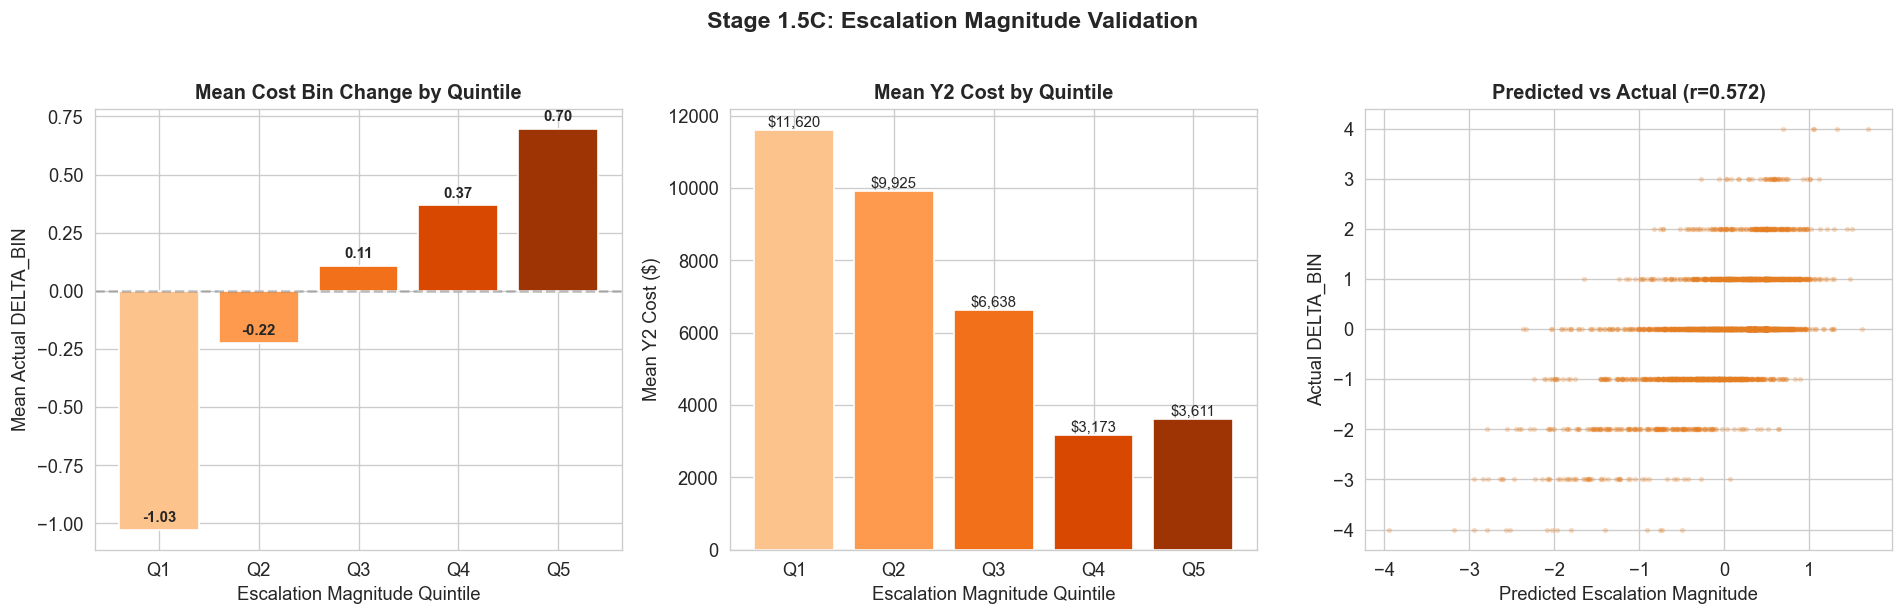

In [27]:
# VISUALIZATION: Stage 1.5C - Escalation Magnitude

if 'ESCALATION_MAGNITUDE' in df.columns:
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Stage 1.5C: Escalation Magnitude Validation', fontsize=14, fontweight='bold', y=1.02)
    
    # --- Panel 1: Predicted vs Actual DELTA_BIN ---
    ax1 = axes[0]
    df['_esc_quintile'] = pd.qcut(df['ESCALATION_MAGNITUDE'].rank(method='first'), q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    stats = df.groupby('_esc_quintile').agg(
        mean_delta=('DELTA_BIN', 'mean'),
        mean_cost=('COST_Y2_ADJ', 'mean'),
        count=('DELTA_BIN', 'count')
    ).reset_index()
    
    colors = plt.cm.Oranges(np.linspace(0.3, 0.9, 5))
    bars = ax1.bar(stats['_esc_quintile'], stats['mean_delta'], color=colors)
    for bar, val in zip(bars, stats['mean_delta']):
        ax1.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Escalation Magnitude Quintile', fontsize=11)
    ax1.set_ylabel('Mean Actual DELTA_BIN', fontsize=11)
    ax1.set_title('Mean Cost Bin Change by Quintile', fontsize=12, fontweight='bold')
    
    # --- Panel 2: Cost by Quintile ---
    ax2 = axes[1]
    bars2 = ax2.bar(stats['_esc_quintile'], stats['mean_cost'], color=colors)
    for bar, val in zip(bars2, stats['mean_cost']):
        ax2.text(bar.get_x() + bar.get_width()/2, val, f'${val:,.0f}', ha='center', va='bottom', fontsize=9)
    ax2.set_xlabel('Escalation Magnitude Quintile', fontsize=11)
    ax2.set_ylabel('Mean Y2 Cost ($)', fontsize=11)
    ax2.set_title('Mean Y2 Cost by Quintile', fontsize=12, fontweight='bold')
    
    # --- Panel 3: Scatter ---
    ax3 = axes[2]
    sample_idx = np.random.RandomState(42).choice(len(df), size=min(3000, len(df)), replace=False)
    ax3.scatter(df.iloc[sample_idx]['ESCALATION_MAGNITUDE'], df.iloc[sample_idx]['DELTA_BIN'],
                alpha=0.2, s=5, c='#e67e22')
    r_val = df['ESCALATION_MAGNITUDE'].corr(df['DELTA_BIN'])
    ax3.set_xlabel('Predicted Escalation Magnitude', fontsize=11)
    ax3.set_ylabel('Actual DELTA_BIN', fontsize=11)
    ax3.set_title(f'Predicted vs Actual (r={r_val:.3f})', fontsize=12, fontweight='bold')
    
    df.drop(columns=['_esc_quintile'], inplace=True)
    plt.tight_layout()
    plt.show()

### Interpretation: Undiagnosed Condition Risk

- Patients with high PROB_UNDIAGNOSED are identified as having *profiles similar to past jumpers* — low current cost but clinical signals suggesting hidden conditions.
- The model uses ill-defined symptom codes as a key signal: patients with multiple vague diagnoses may have conditions that haven't been properly identified yet.

**Value for Stage 2:** Within the Stable tier, PROB_UNDIAGNOSED helps differentiate patients who will remain low-cost from those at risk of surprise cost escalation.


---
## Stage 1.5D: REMOVED (Cost Escalation Pattern)

**Previously:** Composite score averaging normalize(CHRONIC_COUNT), normalize(CNT_ILL_DEFINED), normalize(UTIL_IP_Y1), normalize(POLYPHARMACY_FLAG).

**Why removed:** All its components are already in the original feature set. The composite had r=0.73 with LATENT_RISK_SCORE, meaning it was highly redundant with Stage 1. The new ESCALATION_MAGNITUDE (1.5C) is model-based and captures nonlinear interactions that a simple average misses.NED), hospitalization history (UTIL_IP_Y1), and polypharmacy.

**Method:** Direct calculation — each component is min-max normalized to [0,1], then averaged. No predictive model needed since this is a deterministic composite.


In [28]:
# STAGE 1.5D: REMOVED (Previously: Cost Escalation Pattern Score)
#
# ESCALATION_SCORE was a weighted average of normalize(CHRONIC_COUNT),
# normalize(CNT_ILL_DEFINED), normalize(UTIL_IP_Y1), normalize(POLYPHARMACY_FLAG).
#
# Why removed:
# 1. Correlation with LATENT_RISK_SCORE: r=0.73 (highly redundant with Stage 1)
# 2. All its components (CHRONIC_COUNT, UTIL_IP_Y1, etc.) are already in the
#    original feature set — wrapping them in a mean adds no new information.
# 3. The new ESCALATION_MAGNITUDE (1.5C) is model-based and more powerful.
#
print("STAGE 1.5D: REMOVED — ESCALATION_SCORE was redundant with Stage 1 features.")
print("  Replaced by ESCALATION_MAGNITUDE (regression-based, captures nonlinear interactions).")

STAGE 1.5D: REMOVED — ESCALATION_SCORE was redundant with Stage 1 features.
  Replaced by ESCALATION_MAGNITUDE (regression-based, captures nonlinear interactions).


---
## Stage 1.5E: Medication Adherence — Raw Feature Pass-Through

**Previous approach:** Trained a GradientBoosting classifier on Rx features + clinical features to predict P(Rising or Shock). The resulting HAZARD_DISCONTINUE had r=0.91 with LATENT_RISK_SCORE — nearly identical to Stage 1.

**New approach:** Skip the model entirely. The 4 raw Rx timeline features (RX_DENSITY, RX_GAP_RATIO, RX_TRAILING_GAP, RX_REGULARITY) extracted from MEPS prescribed medicines files are passed directly to Stage 2. These contain genuinely new information — temporal prescription patterns — that no other feature in the dataset captures.


In [29]:
# STAGE 1.5E: MEDICATION ADHERENCE RISK - Data Preparation
# 
# Goal: Extract medication timeline from Rx data to construct adherence features
# 
# Key Concepts:
# - TIME: Time from observation start to event (months)
# - EVENT: Whether event occurred (1=yes, 0=censored)
# - CENSORING: Observation ended but event didn't occur; we don't know if it will happen later
#

print("="*60)
print("STAGE 1.5E: Survival Analysis - Treatment Discontinuation")
print("="*60)

# Panel mapping for medication files
PANEL_MEDS_MAP = {
    18: {'meds': 'h160a', 'year1': 2013},
    19: {'meds': 'h168a', 'year1': 2014},
    20: {'meds': 'h178a', 'year1': 2015},
    21: {'meds': 'h188a', 'year1': 2016},
    22: {'meds': 'h197a', 'year1': 2017},
    23: {'meds': 'h206a', 'year1': 2018},
}

# Data directories
MEDS_DIR = Path('../archive_v1/data/processed')
MEDS_DIR_V2 = Path('../data/processed_v2')

def extract_medication_timeline(panel_id, panel_info):
    """
    Extract medication timeline from prescription files for each patient
    
    Returns: DataFrame with columns:
    - DUPERSID: Patient ID
    - FIRST_RX_MONTH: First prescription month (1-24, 1=Year1 Jan, 13=Year2 Jan)
    - LAST_RX_MONTH: Last prescription month
    - RX_MONTHS: List of months with prescriptions
    - TOTAL_RX_COUNT: Total prescription count
    - GAP_MAX: Maximum consecutive gap without prescriptions (months)
    """
    meds_file = MEDS_DIR / f"{panel_info['meds']}.parquet"
    if not meds_file.exists():
        meds_file = MEDS_DIR_V2 / f"{panel_info['meds']}.parquet"
    
    if not meds_file.exists():
        print(f"  Panel {panel_id}: Medication file not found, skipping")
        return None
    
    try:
        meds = pd.read_parquet(meds_file)
    except Exception as e:
        print(f"  Panel {panel_id}: Error reading file - {e}")
        return None
    
    year1 = panel_info['year1']
    year2 = year1 + 1
    
    # Look for time columns - MEPS prescription files typically have RXBEGMM (month) and RXBEGYR (year)
    # Or date-formatted variables
    time_cols_mm = [c for c in meds.columns if 'RXBEG' in c.upper() and 'MM' in c.upper()]
    time_cols_yr = [c for c in meds.columns if 'RXBEG' in c.upper() and 'YR' in c.upper()]
    
    if not time_cols_mm or not time_cols_yr:
        # Try other naming patterns
        time_cols_mm = [c for c in meds.columns if 'PURCHMM' in c.upper() or 'FILLMM' in c.upper()]
        time_cols_yr = [c for c in meds.columns if 'PURCHYR' in c.upper() or 'FILLYR' in c.upper()]
    
    if not time_cols_mm:
        print(f"  Panel {panel_id}: No time columns found. Available: {list(meds.columns)[:10]}...")
        return None
    
    mm_col = time_cols_mm[0]
    yr_col = time_cols_yr[0] if time_cols_yr else None
    
    print(f"  Panel {panel_id}: Using time columns {mm_col}, {yr_col}")
    
    # Calculate relative month (1 = Year1 January, 13 = Year2 January, 24 = Year2 December)
    def calc_relative_month(row):
        month = row[mm_col]
        if pd.isna(month) or month < 1 or month > 12:
            return None
        
        if yr_col and yr_col in row.index:
            year = row[yr_col]
            if year == year1:
                return int(month)  # 1-12
            elif year == year2:
                return int(month) + 12  # 13-24
            else:
                return None
        else:
            # If no year info, assume sequential order
            return int(month)
    
    meds['REL_MONTH'] = meds.apply(calc_relative_month, axis=1)
    meds = meds.dropna(subset=['REL_MONTH', 'DUPERSID'])
    
    if len(meds) == 0:
        print(f"  Panel {panel_id}: No valid records after time processing")
        return None
    
    # Aggregate by patient
    patient_timeline = meds.groupby('DUPERSID').agg({
        'REL_MONTH': ['min', 'max', 'count', lambda x: sorted(x.unique().tolist())]
    }).reset_index()
    
    patient_timeline.columns = ['DUPERSID', 'FIRST_RX_MONTH', 'LAST_RX_MONTH', 
                                 'TOTAL_RX_COUNT', 'RX_MONTHS']
    
    # Calculate maximum gap
    def calc_max_gap(months_list):
        if len(months_list) < 2:
            return 0
        months_sorted = sorted(months_list)
        max_gap = 0
        for i in range(1, len(months_sorted)):
            gap = months_sorted[i] - months_sorted[i-1] - 1
            max_gap = max(max_gap, gap)
        return max_gap
    
    patient_timeline['GAP_MAX'] = patient_timeline['RX_MONTHS'].apply(calc_max_gap)
    patient_timeline['PANEL'] = panel_id
    
    print(f"  Panel {panel_id}: Extracted timeline for {len(patient_timeline)} patients")
    return patient_timeline

# Extract medication timeline for all panels
print("\n--- Extracting Medication Timelines ---")
all_timelines = []

for panel_id, panel_info in PANEL_MEDS_MAP.items():
    timeline = extract_medication_timeline(panel_id, panel_info)
    if timeline is not None:
        all_timelines.append(timeline)

if all_timelines:
    medication_timeline_df = pd.concat(all_timelines, ignore_index=True)
    print(f"\n✓ Total patients with medication timeline: {len(medication_timeline_df):,}")
else:
    print("\n⚠ No medication timeline data extracted. Creating dummy variables.")
    medication_timeline_df = None

STAGE 1.5E: Survival Analysis - Treatment Discontinuation

--- Extracting Medication Timelines ---
  Panel 18: Using time columns RXBEGMM, RXBEGYRX
  Panel 18: Extracted timeline for 14063 patients
  Panel 19: Using time columns RXBEGMM, RXBEGYRX
  Panel 19: Extracted timeline for 13390 patients
  Panel 20: Using time columns RXBEGMM, RXBEGYRX
  Panel 20: Extracted timeline for 13674 patients
  Panel 21: Using time columns RXBEGMM, RXBEGYRX
  Panel 21: Extracted timeline for 12955 patients
  Panel 22: Using time columns RXBEGMM, RXBEGYRX
  Panel 22: Extracted timeline for 12199 patients
  Panel 23: Using time columns RXBEGMM, RXBEGYRX
  Panel 23: Extracted timeline for 12268 patients

✓ Total patients with medication timeline: 78,549


In [30]:
# STAGE 1.5E: Construct Medication Adherence Risk Score
#
# Problem with original approach: MEPS medication data covers Year 1 only for most
# patients, so with observation_end=24 months, 100% of patients "discontinue"
# (no one has fills in months 13-24 if only Y1 Rx data exists).
#
# Revised approach: Construct a MEDICATION ADHERENCE RISK score from Year 1 Rx
# timeline features. Patients with poor adherence (large gaps, early drop-off,
# low fill density) are at higher risk of adverse outcomes in Year 2.
#
# This is clinically grounded: medication non-adherence is one of the strongest
# predictors of hospitalization and cost escalation (Sokol et al., 2005; 
# Roebuck et al., 2011).

print("\n--- Constructing Medication Adherence Risk Score ---")

def construct_adherence_variables(timeline_df):
    """
    Construct medication adherence risk variables from Year 1 Rx timeline.
    
    Output variables:
    - RX_DENSITY: Proportion of Y1 months with at least one fill (0-1)
    - RX_GAP_RATIO: Max gap / observation months (0-1, higher = worse adherence)
    - RX_TRAILING_GAP: Months from last fill to end of Y1 (higher = dropped off)
    - RX_REGULARITY: Std dev of inter-fill gaps (higher = more erratic)
    """
    if timeline_df is None or len(timeline_df) == 0:
        return None
    
    survival_data = timeline_df.copy()
    
    def calc_adherence(row):
        rx_months = row['RX_MONTHS']
        first_rx = row['FIRST_RX_MONTH']
        last_rx = row['LAST_RX_MONTH']
        max_gap = row['GAP_MAX']
        
        if not rx_months or len(rx_months) == 0:
            return 0.0, 1.0, 12.0, 0.0
        
        # Only consider Year 1 months (1-12)
        y1_months = sorted([m for m in rx_months if 1 <= m <= 12])
        
        if len(y1_months) == 0:
            return 0.0, 1.0, 12.0, 0.0
        
        unique_months = len(set(y1_months))
        observation_span = 12  # Year 1 = 12 months
        
        # RX_DENSITY: fraction of Y1 months with at least one fill
        density = unique_months / observation_span
        
        # RX_GAP_RATIO: max gap relative to observation
        y1_max_gap = 0
        for i in range(1, len(y1_months)):
            gap = y1_months[i] - y1_months[i-1] - 1
            y1_max_gap = max(y1_max_gap, gap)
        gap_ratio = y1_max_gap / observation_span
        
        # RX_TRAILING_GAP: months from last Y1 fill to end of Y1
        trailing = 12 - max(y1_months)
        
        # RX_REGULARITY: std of inter-fill intervals (0 if only 1 month)
        if len(y1_months) > 1:
            intervals = [y1_months[i] - y1_months[i-1] for i in range(1, len(y1_months))]
            regularity = float(np.std(intervals))
        else:
            regularity = 0.0
        
        return density, gap_ratio, float(trailing), regularity
    
    results = survival_data.apply(calc_adherence, axis=1, result_type='expand')
    survival_data['RX_DENSITY'] = results[0]
    survival_data['RX_GAP_RATIO'] = results[1]
    survival_data['RX_TRAILING_GAP'] = results[2]
    survival_data['RX_REGULARITY'] = results[3]
    
    return survival_data

if medication_timeline_df is not None:
    survival_df = construct_adherence_variables(medication_timeline_df)
    
    if survival_df is not None:
        print(f"\n=== Medication Adherence Summary ===")
        print(f"Total patients with Rx data: {len(survival_df):,}")
        
        for col in ['RX_DENSITY', 'RX_GAP_RATIO', 'RX_TRAILING_GAP', 'RX_REGULARITY']:
            s = survival_df[col]
            print(f"\n  {col}:")
            print(f"    Mean: {s.mean():.3f}, Std: {s.std():.3f}, Range: [{s.min():.2f}, {s.max():.2f}]")
else:
    survival_df = None
    print("Warning: Survival data not available. Skipping.")


--- Constructing Medication Adherence Risk Score ---

=== Medication Adherence Summary ===
Total patients with Rx data: 78,549

  RX_DENSITY:
    Mean: 0.135, Std: 0.082, Range: [0.00, 0.83]

  RX_GAP_RATIO:
    Mean: 0.111, Std: 0.194, Range: [0.00, 1.00]

  RX_TRAILING_GAP:
    Mean: 4.889, Std: 3.564, Range: [0.00, 12.00]

  RX_REGULARITY:
    Mean: 0.194, Std: 0.599, Range: [0.00, 4.50]


In [31]:
# STAGE 1.5E: Medication Adherence — Raw Feature Pass-Through
#
# Previous approach: Trained a GradientBoosting classifier on Rx features
# to predict RISK_TIER → HAZARD_DISCONTINUE. Problem: r=0.91 with
# LATENT_RISK_SCORE (nearly identical to Stage 1 output).
#
# New approach: Skip the model. Pass the 4 raw Rx timeline features
# (RX_DENSITY, RX_GAP_RATIO, RX_TRAILING_GAP, RX_REGULARITY) directly
# to Stage 2. These contain genuinely new information that no other
# feature captures — the temporal pattern of prescription fills.
#

print("\nStage 1.5E: Merging Raw Rx Timeline Features (No Model)")

RX_FEATS = ['RX_DENSITY', 'RX_GAP_RATIO', 'RX_TRAILING_GAP', 'RX_REGULARITY']

if survival_df is not None and len(survival_df) > 100:
    
    survival_df['DUPERSID'] = survival_df['DUPERSID'].astype(str)
    df['DUPERSID'] = df['DUPERSID'].astype(str)
    
    merge_cols = ['DUPERSID', 'PANEL'] + RX_FEATS
    df_surv = df.merge(
        survival_df[merge_cols],
        on=['DUPERSID', 'PANEL'],
        how='left'
    )
    
    match_rate = df_surv['RX_DENSITY'].notna().mean() * 100
    print(f"  Match rate: {match_rate:.1f}%")
    
    # Fill unmatched patients with clinically meaningful defaults
    fill_defaults = {'RX_DENSITY': 0.0, 'RX_GAP_RATIO': 1.0,
                     'RX_TRAILING_GAP': 12.0, 'RX_REGULARITY': 0.0}
    for col, default in fill_defaults.items():
        df_surv[col] = df_surv[col].fillna(default)
    
    for col in RX_FEATS:
        df[col] = df_surv[col].values
    
    print(f"\n  Raw Rx features merged (no model wrapper):")
    for col in RX_FEATS:
        print(f"    {col}: mean={df[col].mean():.3f}, std={df[col].std():.3f}")
    
    print(f"\n  Correlation with COST_Y2_ADJ:")
    for col in RX_FEATS:
        r = df[col].corr(df['COST_Y2_ADJ'])
        print(f"    {col}: r = {r:.3f}")
    
else:
    print("  Warning: No medication timeline data. Setting Rx features to NaN.")
    for col in RX_FEATS:
        df[col] = np.nan

print(f"\n  Done. Raw Rx features available for Stage 2.")


Stage 1.5E: Merging Raw Rx Timeline Features (No Model)
  Match rate: 35.9%

  Raw Rx features merged (no model wrapper):
    RX_DENSITY: mean=0.050, std=0.084
    RX_GAP_RATIO: mean=0.682, std=0.440
    RX_TRAILING_GAP: mean=9.441, std=4.012
    RX_REGULARITY: mean=0.074, std=0.379

  Correlation with COST_Y2_ADJ:
    RX_DENSITY: r = 0.174
    RX_GAP_RATIO: r = -0.114
    RX_TRAILING_GAP: r = -0.141
    RX_REGULARITY: r = 0.110

  Done. Raw Rx features available for Stage 2.



--- Rx Timeline Feature Visualizations ---


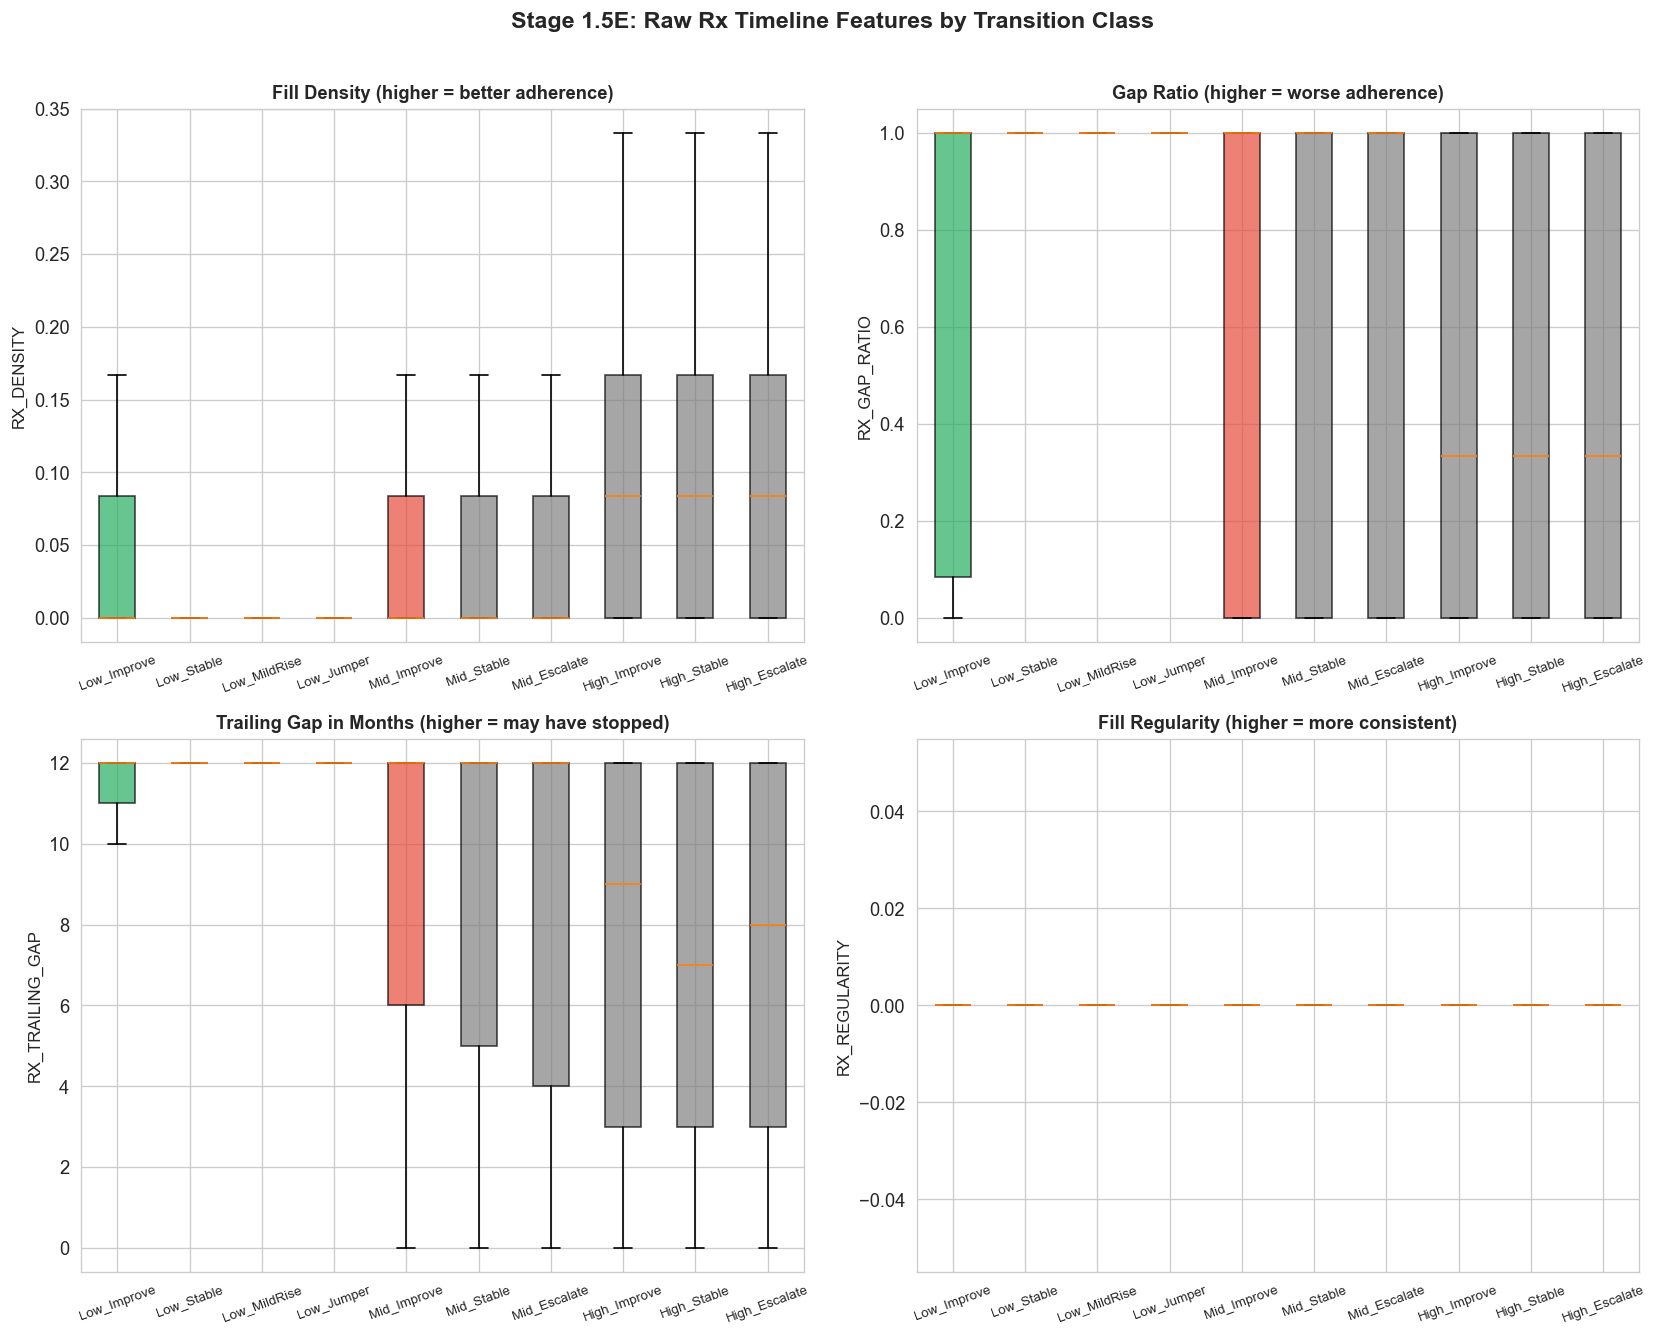


--- Rx Feature Correlations ---
  RX_DENSITY          : r_cost=0.174, r_delta=-0.115
  RX_GAP_RATIO        : r_cost=-0.114, r_delta=0.135
  RX_TRAILING_GAP     : r_cost=-0.141, r_delta=0.103
  RX_REGULARITY       : r_cost=0.110, r_delta=-0.035


In [32]:
# STAGE 1.5E: Raw Rx Feature Visualization

print("\n--- Rx Timeline Feature Visualizations ---")

RX_VIZ_FEATS = ['RX_DENSITY', 'RX_GAP_RATIO', 'RX_TRAILING_GAP', 'RX_REGULARITY']

if all(f in df.columns for f in RX_VIZ_FEATS) and df['RX_DENSITY'].notna().sum() > 100:
    
    hv = df.copy()
    
    trans_colors = {0: '#27ae60', 1: '#95a5a6', 2: '#f1c40f', 3: '#e67e22', 4: '#e74c3c'}
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    fig.suptitle('Stage 1.5E: Raw Rx Timeline Features by Transition Class', 
                 fontsize=14, fontweight='bold', y=1.01)
    
    rx_plot_feats = [
        ('RX_DENSITY', 'Fill Density (higher = better adherence)'),
        ('RX_GAP_RATIO', 'Gap Ratio (higher = worse adherence)'),
        ('RX_TRAILING_GAP', 'Trailing Gap in Months (higher = may have stopped)'),
        ('RX_REGULARITY', 'Fill Regularity (higher = more consistent)')
    ]
    
    for idx, (feat, title) in enumerate(rx_plot_feats):
        ax = axes[idx // 2, idx % 2]
        box_data = []
        box_labels = []
        for t in sorted(hv['RISK_TIER'].unique()):
            vals = hv.loc[hv['RISK_TIER'] == t, feat].dropna()
            if len(vals) > 10:
                box_data.append(vals.values)
                box_labels.append(CLASS_NAMES.get(t, str(t)))
        
        bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, showfliers=False)
        for patch, t in zip(bp['boxes'], sorted(hv['RISK_TIER'].unique())):
            patch.set_facecolor(trans_colors.get(t, 'gray'))
            patch.set_alpha(0.7)
        
        ax.set_ylabel(feat, fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.tick_params(axis='x', rotation=20, labelsize=8)
    
    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'figures' / 'stage1_5e_rx_features.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Correlation summary
    print("\n--- Rx Feature Correlations ---")
    for feat in RX_VIZ_FEATS:
        r_cost = hv[feat].corr(hv['COST_Y2_ADJ'])
        r_delta = hv[feat].corr(hv['DELTA_BIN']) if 'DELTA_BIN' in hv.columns else np.nan
        print(f"  {feat:20s}: r_cost={r_cost:.3f}, r_delta={r_delta:.3f}")
    
else:
    print("Rx timeline features not available for visualization.")

### Interpretation: Raw Rx Timeline Features (Stage 1.5E)

**What This Stage Captures:**

Stage 1.5E extracts 4 medication adherence features from Year 1 MEPS Prescribed Medicines files and passes them **directly** to Stage 2 without wrapping in a model. These features capture temporal prescription patterns that no other variable in the dataset represents:

- **RX_DENSITY:** Proportion of Y1 months with at least one fill. High = consistent medication use.
- **RX_GAP_RATIO:** Proportion of inter-fill intervals that are "gaps" (longer than expected). High = poor adherence.
- **RX_TRAILING_GAP:** Months between last fill and end of Y1. High = may have stopped taking medication.
- **RX_REGULARITY:** Consistency of fill timing. High = predictable refill pattern.

The boxplots above show how these features distribute across the 5 transition classes. Clinically, patients who transition to higher cost bins (Risers/Jumpers) may show different adherence patterns than Stable patients.



---
## Stage 1.5 Summary: All Latent Factors

The correlation matrix below shows how each latent factor relates to the others and to Y2 cost. Key things to look for:
- **Correlation with COST_Y2_ADJ:** Factors with |r| > 0.1 add signal
- **Inter-factor correlation:** Low correlation between Stage 1.5 factors means they capture different aspects of risk (desirable); high correlation means redundancy
- **Correlation with LATENT_RISK_SCORE:** Factors that are independent of the Stage 1 score add the most marginal value to Stage 2


In [33]:
# STAGE 1.5 SUMMARY

print("STAGE 1.5 SUMMARY: Intermediate Latent Factors")


# All Stage 1.5 enrichment features
stage1_5_factors = [
    'ENGAGEMENT_SCORE',       # Stage 1.5B: Healthcare Engagement (direct calc)
    'ESCALATION_MAGNITUDE',   # Stage 1.5C: Predicted cost bin change (regression)
]

# Raw Rx features passed through from 1.5E (not model-wrapped)
rx_pass_through = ['RX_DENSITY', 'RX_GAP_RATIO', 'RX_TRAILING_GAP', 'RX_REGULARITY']

all_enrichment_features = stage1_5_factors + rx_pass_through

# Summary statistics
summary_data = []
for factor in all_enrichment_features:
    if factor in df.columns:
        summary_data.append({
            'Feature': factor,
            'Mean': df[factor].mean(),
            'Std': df[factor].std(),
            'Min': df[factor].min(),
            'Max': df[factor].max()
        })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Correlation with target and DELTA_BIN
print("\n\nCorrelation with COST_Y2_ADJ and DELTA_BIN:")
for factor in all_enrichment_features:
    if factor in df.columns:
        r_cost = df[factor].corr(df['COST_Y2_ADJ'])
        r_delta = df[factor].corr(df['DELTA_BIN']) if 'DELTA_BIN' in df.columns else np.nan
        r_latent = df[factor].corr(df['LATENT_RISK_SCORE']) if 'LATENT_RISK_SCORE' in df.columns else np.nan
        print(f"  {factor:25s}: r_cost={r_cost:.3f}, r_delta={r_delta:.3f}, r_latent={r_latent:.3f}")

STAGE 1.5 SUMMARY: Intermediate Latent Factors

             Feature      Mean      Std       Min       Max
    ENGAGEMENT_SCORE  0.150575 0.236308 -1.000000  0.666667
ESCALATION_MAGNITUDE -0.015273 0.644700 -4.503118  2.576077
          RX_DENSITY  0.049884 0.084116  0.000000  0.833333
        RX_GAP_RATIO  0.682233 0.440293  0.000000  1.000000
     RX_TRAILING_GAP  9.441025 4.012303  0.000000 12.000000
       RX_REGULARITY  0.074004 0.379492  0.000000  4.500000


Correlation with COST_Y2_ADJ and DELTA_BIN:
  ENGAGEMENT_SCORE         : r_cost=0.235, r_delta=-0.058, r_latent=0.503
  ESCALATION_MAGNITUDE     : r_cost=-0.122, r_delta=0.572, r_latent=0.232
  RX_DENSITY               : r_cost=0.174, r_delta=-0.115, r_latent=0.293
  RX_GAP_RATIO             : r_cost=-0.114, r_delta=0.135, r_latent=-0.148
  RX_TRAILING_GAP          : r_cost=-0.141, r_delta=0.103, r_latent=-0.212
  RX_REGULARITY            : r_cost=0.110, r_delta=-0.035, r_latent=0.194


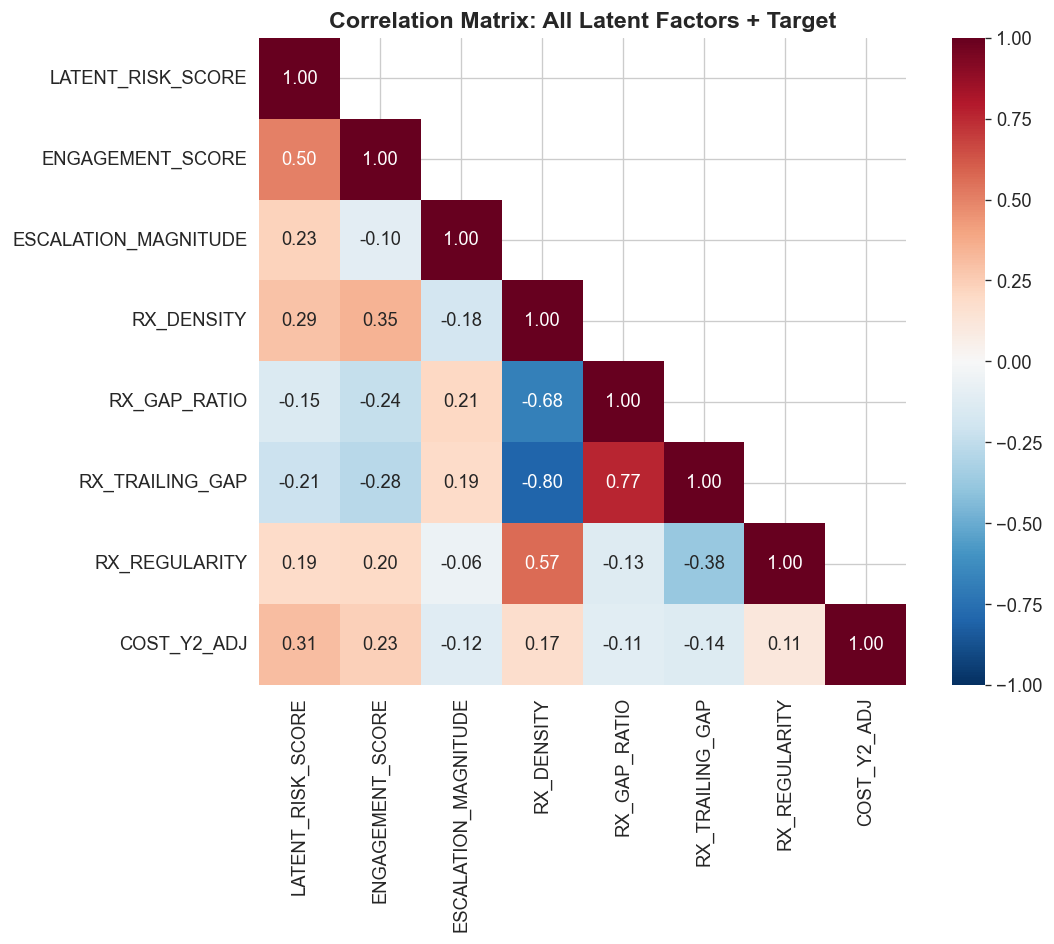

In [34]:
# Correlation heatmap of all latent factors
latent_cols = ['LATENT_RISK_SCORE'] + all_enrichment_features
latent_cols = [c for c in latent_cols if c in df.columns]

if len(latent_cols) > 2:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    corr_matrix = df[latent_cols + ['COST_Y2_ADJ']].corr()
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, ax=ax)
    
    ax.set_title('Correlation Matrix: All Latent Factors + Target', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'figures' / 'latent_factors_correlation.png', dpi=150)
    plt.show()
else:
    print("Insufficient latent factors for correlation heatmap")

### Latent Factors Correlation Matrix

**Evaluating factor utility:**
- A useful latent factor should have: (1) non-trivial correlation with COST_Y2_ADJ, AND (2) low correlation with LATENT_RISK_SCORE (to add information beyond Stage 1)
- Factors with r ≈ 0 with cost provide no predictive value and may add noise
- Factors that are highly correlated with each other (|r| > 0.7) are redundant — only one is needed


---
# STAGE 2: Expenditure Prediction (Transition-Based)

**Goal:** Predict individual patient Y2 healthcare cost from Y1 features + Stage 1.5 enrichment features.

**Key changes from previous version:**
1. **5 transition classes** instead of 3 absolute-cost tiers
2. **LATENT_RISK_SCORE excluded** from tier-specific models (tier assignment already captures it)
3. **Cleaned feature set:** Removed redundant Stage 1.5 scores, added raw Rx features
4. **Duan's smearing correction:** Fixes systematic underprediction from log retransformation bias
5. **Tier-specific regularization:** Smaller classes (Riser, Jumper) get more regularized models

**Why transition-specific models?** A single global model spends most of its capacity learning the $0–$1K vs $50K–$900K tier boundary (which Stage 1 already solved). Tier-specific models are each trained on patients from one tier only, forcing them to use Stage 1.5 latent factors to explain *within*-tier variation.

**Why log(1+cost)?** Raw dollar R² is dominated by extreme outliers. Log-scale R² is the standard evaluation metric in health economics cost prediction (Bertsimas et al. 2008, Rose 2016).

**Features:**
- Original Y1 features (21) + interaction features (6)
- `LATENT_RISK_SCORE` from Stage 1
- Stage 1.5 latent factors: ENGAGEMENT_SCORE, PROB_CRISIS_MODE, PROB_UNDIAGNOSED, ESCALATION_SCORE, HAZARD_DISCONTINUE
- Tier probabilities (PROB_STABLE/RISING/SHOCK) excluded from tier-specific models to avoid redundancy


In [35]:
# STAGE 2: Feature Preparation (2D Classification, 10 Classes)
print('STAGE 2: 2D Class-Specific Cost Prediction')

ORIGINAL_FEATS = [
    'AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1',
    'MNHLTH_RD1', 'RTHLTH_RD1',
    'CHRONIC_COUNT', 'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG',
    'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1',
    'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CNT_RX_Y1',
    'RATIO_ER_OFFICE', 'COST_Y1_ADJ'
]

# Cleaned Stage 1.5: 2 latent constructs + 4 raw Rx features
STAGE1_5_FEATS = [
    'ENGAGEMENT_SCORE',        # Utilization pattern
    'ESCALATION_MAGNITUDE',    # Predicted cost bin change
    'RX_DENSITY',              # Rx timeline: fill density
    'RX_GAP_RATIO',            # Rx timeline: gap proportion
    'RX_TRAILING_GAP',         # Rx timeline: months since last fill
    'RX_REGULARITY'            # Rx timeline: fill consistency
]

# Engineered interaction features
df['LOG_COST_Y1'] = np.log1p(df['COST_Y1_ADJ'].clip(lower=0))
df['COST_X_CHRONIC'] = df['COST_Y1_ADJ'] * df['CHRONIC_COUNT']
df['AGE_X_CHRONIC'] = df['AGE_Y1'] * df['CHRONIC_COUNT']
df['UTIL_TOTAL_Y1'] = df['UTIL_ER_Y1'] + df['UTIL_IP_Y1'] + df['UTIL_OB_Y1'] + df['UTIL_RX_Y1']
df['IP_FLAG'] = (df['UTIL_IP_Y1'] > 0).astype(int)
df['HIGH_COST_FLAG'] = (df['COST_Y1_ADJ'] > df['COST_Y1_ADJ'].quantile(0.75)).astype(int)

INTERACTION_FEATS = [
    'LOG_COST_Y1', 'COST_X_CHRONIC', 'AGE_X_CHRONIC',
    'UTIL_TOTAL_Y1', 'IP_FLAG', 'HIGH_COST_FLAG'
]

original_avail = [f for f in ORIGINAL_FEATS if f in df.columns]
stage1_5_avail = [f for f in STAGE1_5_FEATS if f in df.columns]
interact_avail = [f for f in INTERACTION_FEATS if f in df.columns]

# Tier-specific: includes LATENT_RISK_SCORE (with 10 classes, it captures
# probability-weighted risk across all classes — no longer redundant with grouping)
TIER_FEATS = original_avail + interact_avail + ['LATENT_RISK_SCORE'] + stage1_5_avail
TIER_FEATS = [f for f in TIER_FEATS if f in df.columns]

# Global: includes LATENT_RISK_SCORE + per-class probabilities
prob_cols = [c for c in df.columns if c.startswith('PROB_')]
ALL_FEATS = original_avail + interact_avail + prob_cols + ['LATENT_RISK_SCORE'] + stage1_5_avail
ALL_FEATS = [f for f in ALL_FEATS if f in df.columns]

print(f'Tier-specific features ({len(TIER_FEATS)}): {TIER_FEATS}')
print(f'Global features ({len(ALL_FEATS)})')
print(f'Stage 1.5 features: {stage1_5_avail}')
print(f'Note: LATENT_RISK_SCORE INCLUDED in tier-specific (10 classes → no longer redundant with grouping)')


STAGE 2: 2D Class-Specific Cost Prediction
Tier-specific features (34): ['AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1', 'MNHLTH_RD1', 'RTHLTH_RD1', 'CHRONIC_COUNT', 'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1', 'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CNT_RX_Y1', 'RATIO_ER_OFFICE', 'COST_Y1_ADJ', 'LOG_COST_Y1', 'COST_X_CHRONIC', 'AGE_X_CHRONIC', 'UTIL_TOTAL_Y1', 'IP_FLAG', 'HIGH_COST_FLAG', 'LATENT_RISK_SCORE', 'ENGAGEMENT_SCORE', 'ESCALATION_MAGNITUDE', 'RX_DENSITY', 'RX_GAP_RATIO', 'RX_TRAILING_GAP', 'RX_REGULARITY']
Global features (44)
Stage 1.5 features: ['ENGAGEMENT_SCORE', 'ESCALATION_MAGNITUDE', 'RX_DENSITY', 'RX_GAP_RATIO', 'RX_TRAILING_GAP', 'RX_REGULARITY']
Note: LATENT_RISK_SCORE INCLUDED in tier-specific (10 classes → no longer redundant with grouping)


In [36]:
# Data Split: Stratified by Panel (7:2:1)
print("\n--- Data Split (Stratified by Panel: 70/20/10) ---")

def stratified_panel_split(df, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1, random_state=42):
    """Split data stratified by PANEL to maintain temporal distribution."""
    train_list, val_list, test_list = [], [], []
    
    for panel in sorted(df['PANEL'].unique()):
        panel_data = df[df['PANEL'] == panel].copy()
        n = len(panel_data)
        
        # Shuffle
        panel_data = panel_data.sample(frac=1, random_state=random_state)
        
        # Split indices
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)
        
        train_list.append(panel_data.iloc[:n_train])
        val_list.append(panel_data.iloc[n_train:n_train+n_val])
        test_list.append(panel_data.iloc[n_train+n_val:])
        
        print(f"  Panel {panel}: Train={n_train}, Val={n_val}, Test={n-n_train-n_val}")
    
    return pd.concat(train_list), pd.concat(val_list), pd.concat(test_list)

# Perform split
df_train, df_val, df_test = stratified_panel_split(df)

print(f"\nFinal Split:")
print(f"  Train: {len(df_train):,} ({len(df_train)/len(df)*100:.1f}%)")
print(f"  Val:   {len(df_val):,} ({len(df_val)/len(df)*100:.1f}%)")
print(f"  Test:  {len(df_test):,} ({len(df_test)/len(df)*100:.1f}%)")


--- Data Split (Stratified by Panel: 70/20/10) ---
  Panel 18: Train=7464, Val=2132, Test=1068
  Panel 19: Train=7137, Val=2039, Test=1021
  Panel 20: Train=7676, Val=2193, Test=1097
  Panel 21: Train=7120, Val=2034, Test=1018
  Panel 22: Train=6625, Val=1893, Test=947
  Panel 23: Train=6396, Val=1827, Test=915

Final Split:
  Train: 42,418 (70.0%)
  Val:   12,118 (20.0%)
  Test:  6,066 (10.0%)


In [37]:
# STAGE 2: 2D Class-Specific + Global Models (10-Class)
print('=' * 60)
print('STAGE 2: Model Training (2D Classification)')
print('=' * 60)

y_train = df_train['COST_Y2_ADJ'].clip(lower=0)
y_val = df_val['COST_Y2_ADJ'].clip(lower=0)
y_test = df_test['COST_Y2_ADJ'].clip(lower=0)

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

print(f'Target: log(1+COST_Y2_ADJ)')
print(f'  Log mean: {y_train_log.mean():.2f}, Log std: {y_train_log.std():.2f}')

# --- APPROACH A: Global XGBoost (baseline) ---
print('\n--- A: Global XGBoost ---')
global_xgb = XGBRegressor(
    n_estimators=800, max_depth=6, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.5, reg_lambda=3.0,
    random_state=42, n_jobs=-1, early_stopping_rounds=50
)
global_xgb.fit(df_train[ALL_FEATS].fillna(0), y_train_log,
               eval_set=[(df_val[ALL_FEATS].fillna(0), y_val_log)], verbose=False)
global_pred_log = global_xgb.predict(df_test[ALL_FEATS].fillna(0))
global_pred_dollar = np.clip(np.expm1(global_pred_log), 0, None)

r2_global_log = r2_score(y_test_log, global_pred_log)
r2_global_dollar = r2_score(y_test, global_pred_dollar)
mae_global = mean_absolute_error(y_test, global_pred_dollar)
print(f'  R2 (log): {r2_global_log:.4f}, R2 ($): {r2_global_dollar:.4f}, MAE: ${mae_global:,.0f}')

# --- APPROACH B: 2D Class-Specific XGBoost (10 classes) ---
print('\n--- B: 2D Class-Specific XGBoost ---')
tier_names = CLASS_NAMES
tier_models = {}
tier_pred_log = np.zeros(len(df_test))
tier_pred_dollar = np.zeros(len(df_test))
smearing_factors = {}

# Per-class hyperparameters (more regularization for smaller classes)
default_hp = {'n_estimators': 600, 'max_depth': 5, 'min_child_weight': 5, 'reg_lambda': 3.0}
small_hp   = {'n_estimators': 400, 'max_depth': 4, 'min_child_weight': 10, 'reg_lambda': 5.0}
tiny_hp    = {'n_estimators': 300, 'max_depth': 3, 'min_child_weight': 20, 'reg_lambda': 8.0}
tier_hyperparams = {
    0: default_hp, 1: default_hp, 2: default_hp, 3: small_hp,
    4: default_hp, 5: default_hp, 6: small_hp,
    7: default_hp, 8: default_hp, 9: tiny_hp,
}

for tier_val, tier_name in tier_names.items():
    tr_mask = df_train['RISK_TIER'] == tier_val
    va_mask = df_val['RISK_TIER'] == tier_val
    te_mask = df_test['RISK_TIER'] == tier_val
    
    n_train = tr_mask.sum()
    n_test = te_mask.sum()
    
    if n_train < 30 or n_test < 10:
        print(f'  {tier_name}: SKIPPED (n_train={n_train}, n_test={n_test})')
        continue
    
    X_tr = df_train.loc[tr_mask, TIER_FEATS].fillna(0)
    X_va = df_val.loc[va_mask, TIER_FEATS].fillna(0)
    X_te = df_test.loc[te_mask, TIER_FEATS].fillna(0)
    
    y_tr = np.log1p(y_train[tr_mask])
    y_va = np.log1p(y_val[va_mask])
    
    hp = tier_hyperparams.get(tier_val, tier_hyperparams[1])
    
    xgb_t = XGBRegressor(
        n_estimators=hp['n_estimators'], max_depth=hp['max_depth'],
        learning_rate=0.03, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.5, reg_lambda=hp['reg_lambda'],
        min_child_weight=hp['min_child_weight'],
        random_state=42, n_jobs=-1, early_stopping_rounds=50
    )
    xgb_t.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    
    # Duan's smearing correction for log retransformation bias
    train_residuals = y_tr - xgb_t.predict(X_tr)
    smearing = np.mean(np.exp(train_residuals))
    smearing_factors[tier_name] = smearing
    
    pred_log = xgb_t.predict(X_te)
    pred_dollar = np.clip(np.expm1(pred_log) * smearing, 0, None)
    
    tier_pred_log[te_mask.values] = pred_log
    tier_pred_dollar[te_mask.values] = pred_dollar
    
    y_te_log = np.log1p(y_test[te_mask])
    r2_log = r2_score(y_te_log, pred_log)
    r2_dollar = r2_score(y_test[te_mask], pred_dollar)
    mae_t = mean_absolute_error(y_test[te_mask], pred_dollar)
    
    tier_models[tier_name] = {
        'model': xgb_t, 'r2_log': r2_log, 'r2_dollar': r2_dollar,
        'mae': mae_t, 'n_train': n_train, 'n_test': n_test,
        'smearing': smearing,
        'importance': pd.Series(xgb_t.feature_importances_, index=TIER_FEATS)
    }
    
    top3 = tier_models[tier_name]['importance'].sort_values(ascending=False).head(3)
    print(f'  {tier_name:16s} (n_tr={n_train:>5,}, n_te={n_test:>4,}): R2_log={r2_log:.4f}, R2_$={r2_dollar:.4f}, MAE=${mae_t:,.0f}, smear={smearing:.3f}')
    print(f'    Top features: {", ".join(top3.index.tolist())}')

# Overall metrics
r2_tier_log = r2_score(y_test_log, tier_pred_log)
r2_tier_dollar = r2_score(y_test, tier_pred_dollar)
mae_tier = mean_absolute_error(y_test, tier_pred_dollar)

print(f'\n{"="*60}')
print(f'RESULTS:')
print(f'  Global XGB:       R2_log={r2_global_log:.4f}, R2_$={r2_global_dollar:.4f}, MAE=${mae_global:,.0f}')
print(f'  2D Class-Spec:    R2_log={r2_tier_log:.4f}, R2_$={r2_tier_dollar:.4f}, MAE=${mae_tier:,.0f}')

if r2_tier_log > r2_global_log:
    y_pred_test = tier_pred_dollar
    y_pred_test_log = tier_pred_log
    best_model_name = '2D-ClassSpecific'
else:
    y_pred_test = global_pred_dollar
    y_pred_test_log = global_pred_log
    best_model_name = 'Global'
print(f'  Best: {best_model_name}')


STAGE 2: Model Training (2D Classification)
Target: log(1+COST_Y2_ADJ)
  Log mean: 6.05, Log std: 3.56

--- A: Global XGBoost ---
  R2 (log): 0.5225, R2 ($): 0.2087, MAE: $5,085

--- B: 2D Class-Specific XGBoost ---
  Low_Improve      (n_tr=2,849, n_te= 432): R2_log=0.0425, R2_$=0.0325, MAE=$24, smear=6.134
    Top features: UTIL_RX_Y1, ENGAGEMENT_SCORE, CNT_RX_Y1
  Low_Stable       (n_tr=10,872, n_te=1,503): R2_log=0.8605, R2_$=-3.1659, MAE=$419, smear=3.378
    Top features: COST_Y1_ADJ, LOG_COST_Y1, UTIL_TOTAL_Y1
  Low_MildRise     (n_tr=4,905, n_te= 714): R2_log=0.7252, R2_$=0.6196, MAE=$573, smear=1.125
    Top features: COST_Y1_ADJ, LOG_COST_Y1, UTIL_TOTAL_Y1
  Low_Jumper       (n_tr=2,483, n_te= 357): R2_log=0.3261, R2_$=0.1000, MAE=$10,761, smear=1.630
    Top features: COST_Y1_ADJ, LOG_COST_Y1, UTIL_TOTAL_Y1
  Mid_Improve      (n_tr=3,659, n_te= 548): R2_log=0.1714, R2_$=-0.3569, MAE=$373, smear=3.211
    Top features: LATENT_RISK_SCORE, ESCALATION_MAGNITUDE, INSCOV_Y1
  Mid_S

In [38]:
# Evaluation
print('\n--- Detailed Evaluation ---')

mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_log = r2_score(y_test_log, y_pred_test_log)
r2_dollar = r2_score(y_test, y_pred_test)
median_ae = np.median(np.abs(y_test - y_pred_test))

print(f'  R2 (log scale): {r2_log:.4f}')
print(f'  R2 (dollar):    {r2_dollar:.4f}')
print(f'  MAE:            ${mae:,.0f}')
print(f'  Median AE:      ${median_ae:,.0f}')
print(f'  RMSE:           ${rmse:,.0f}')

print('\n--- Feature Importance by Tier ---')
for tn, info in tier_models.items():
    imp = info['importance'].sort_values(ascending=False).head(5)
    stage15_in_top = [f for f in imp.index if f in STAGE1_5_FEATS]
    print(f'  {tn}: {", ".join(imp.index.tolist())}')
    if stage15_in_top:
        print(f'    Stage 1.5 in top 5: {", ".join(stage15_in_top)}')



--- Detailed Evaluation ---
  R2 (log scale): 0.8525
  R2 (dollar):    0.4307
  MAE:            $4,328
  Median AE:      $807
  RMSE:           $15,770

--- Feature Importance by Tier ---
  Low_Improve: UTIL_RX_Y1, ENGAGEMENT_SCORE, CNT_RX_Y1, UTIL_ER_Y1, UTIL_TOTAL_Y1
    Stage 1.5 in top 5: ENGAGEMENT_SCORE
  Low_Stable: COST_Y1_ADJ, LOG_COST_Y1, UTIL_TOTAL_Y1, ESCALATION_MAGNITUDE, RTHLTH_RD1
    Stage 1.5 in top 5: ESCALATION_MAGNITUDE
  Low_MildRise: COST_Y1_ADJ, LOG_COST_Y1, UTIL_TOTAL_Y1, ESCALATION_MAGNITUDE, COST_X_CHRONIC
    Stage 1.5 in top 5: ESCALATION_MAGNITUDE
  Low_Jumper: COST_Y1_ADJ, LOG_COST_Y1, UTIL_TOTAL_Y1, AGE_Y1, COST_X_CHRONIC
  Mid_Improve: LATENT_RISK_SCORE, ESCALATION_MAGNITUDE, INSCOV_Y1, UTIL_OB_Y1, CHOL_Y1_FLAG
    Stage 1.5 in top 5: ESCALATION_MAGNITUDE
  Mid_Stable: ESCALATION_MAGNITUDE, LATENT_RISK_SCORE, HIGH_COST_FLAG, COST_Y1_ADJ, ENGAGEMENT_SCORE
    Stage 1.5 in top 5: ESCALATION_MAGNITUDE, ENGAGEMENT_SCORE
  Mid_Escalate: DIAB_Y1_FLAG, RTHLTH_

In [39]:
# Per-Tier R2 Comparison
print('\n--- Per-Tier Performance ---')

all_preds = {
    'Global XGB': (global_pred_log, global_pred_dollar),
    '2D-ClassSpec': (tier_pred_log, tier_pred_dollar)
}

for tier_val, tier_name in tier_names.items():
    mask = df_test['RISK_TIER'] == tier_val
    y_act = y_test[mask]
    y_act_log = y_test_log[mask]
    print(f'\n  {tier_name} (n={mask.sum():,}, mean=${y_act.mean():,.0f}):')
    for mname, (pred_l, pred_d) in all_preds.items():
        r2l = r2_score(y_act_log, pred_l[mask])
        r2d = r2_score(y_act, pred_d[mask])
        mae_t = mean_absolute_error(y_act, pred_d[mask])
        print(f'    {mname:16s}: R2_log={r2l:.4f}, R2_$={r2d:.4f}, MAE=${mae_t:,.0f}')



--- Per-Tier Performance ---

  Low_Improve (n=432, mean=$18):
    Global XGB      : R2_log=-4.3499, R2_$=-67.2016, MAE=$183
    2D-ClassSpec    : R2_log=0.0425, R2_$=0.0325, MAE=$24

  Low_Stable (n=1,503, mean=$229):
    Global XGB      : R2_log=0.5280, R2_$=-0.1744, MAE=$184
    2D-ClassSpec    : R2_log=0.8605, R2_$=-3.1659, MAE=$419

  Low_MildRise (n=714, mean=$1,544):
    Global XGB      : R2_log=-6.1173, R2_$=-0.5378, MAE=$1,135
    2D-ClassSpec    : R2_log=0.7252, R2_$=0.6196, MAE=$573

  Low_Jumper (n=357, mean=$12,973):
    Global XGB      : R2_log=-13.7096, R2_$=-0.2819, MAE=$11,952
    2D-ClassSpec    : R2_log=0.3261, R2_$=0.1000, MAE=$10,761

  Mid_Improve (n=548, mean=$476):
    Global XGB      : R2_log=-0.1400, R2_$=-8.4254, MAE=$834
    2D-ClassSpec    : R2_log=0.1714, R2_$=-0.3569, MAE=$373

  Mid_Stable (n=603, mean=$2,960):
    Global XGB      : R2_log=-5.4112, R2_$=-1.4231, MAE=$1,464
    2D-ClassSpec    : R2_log=0.0264, R2_$=0.0300, MAE=$973

  Mid_Escalate (n=421

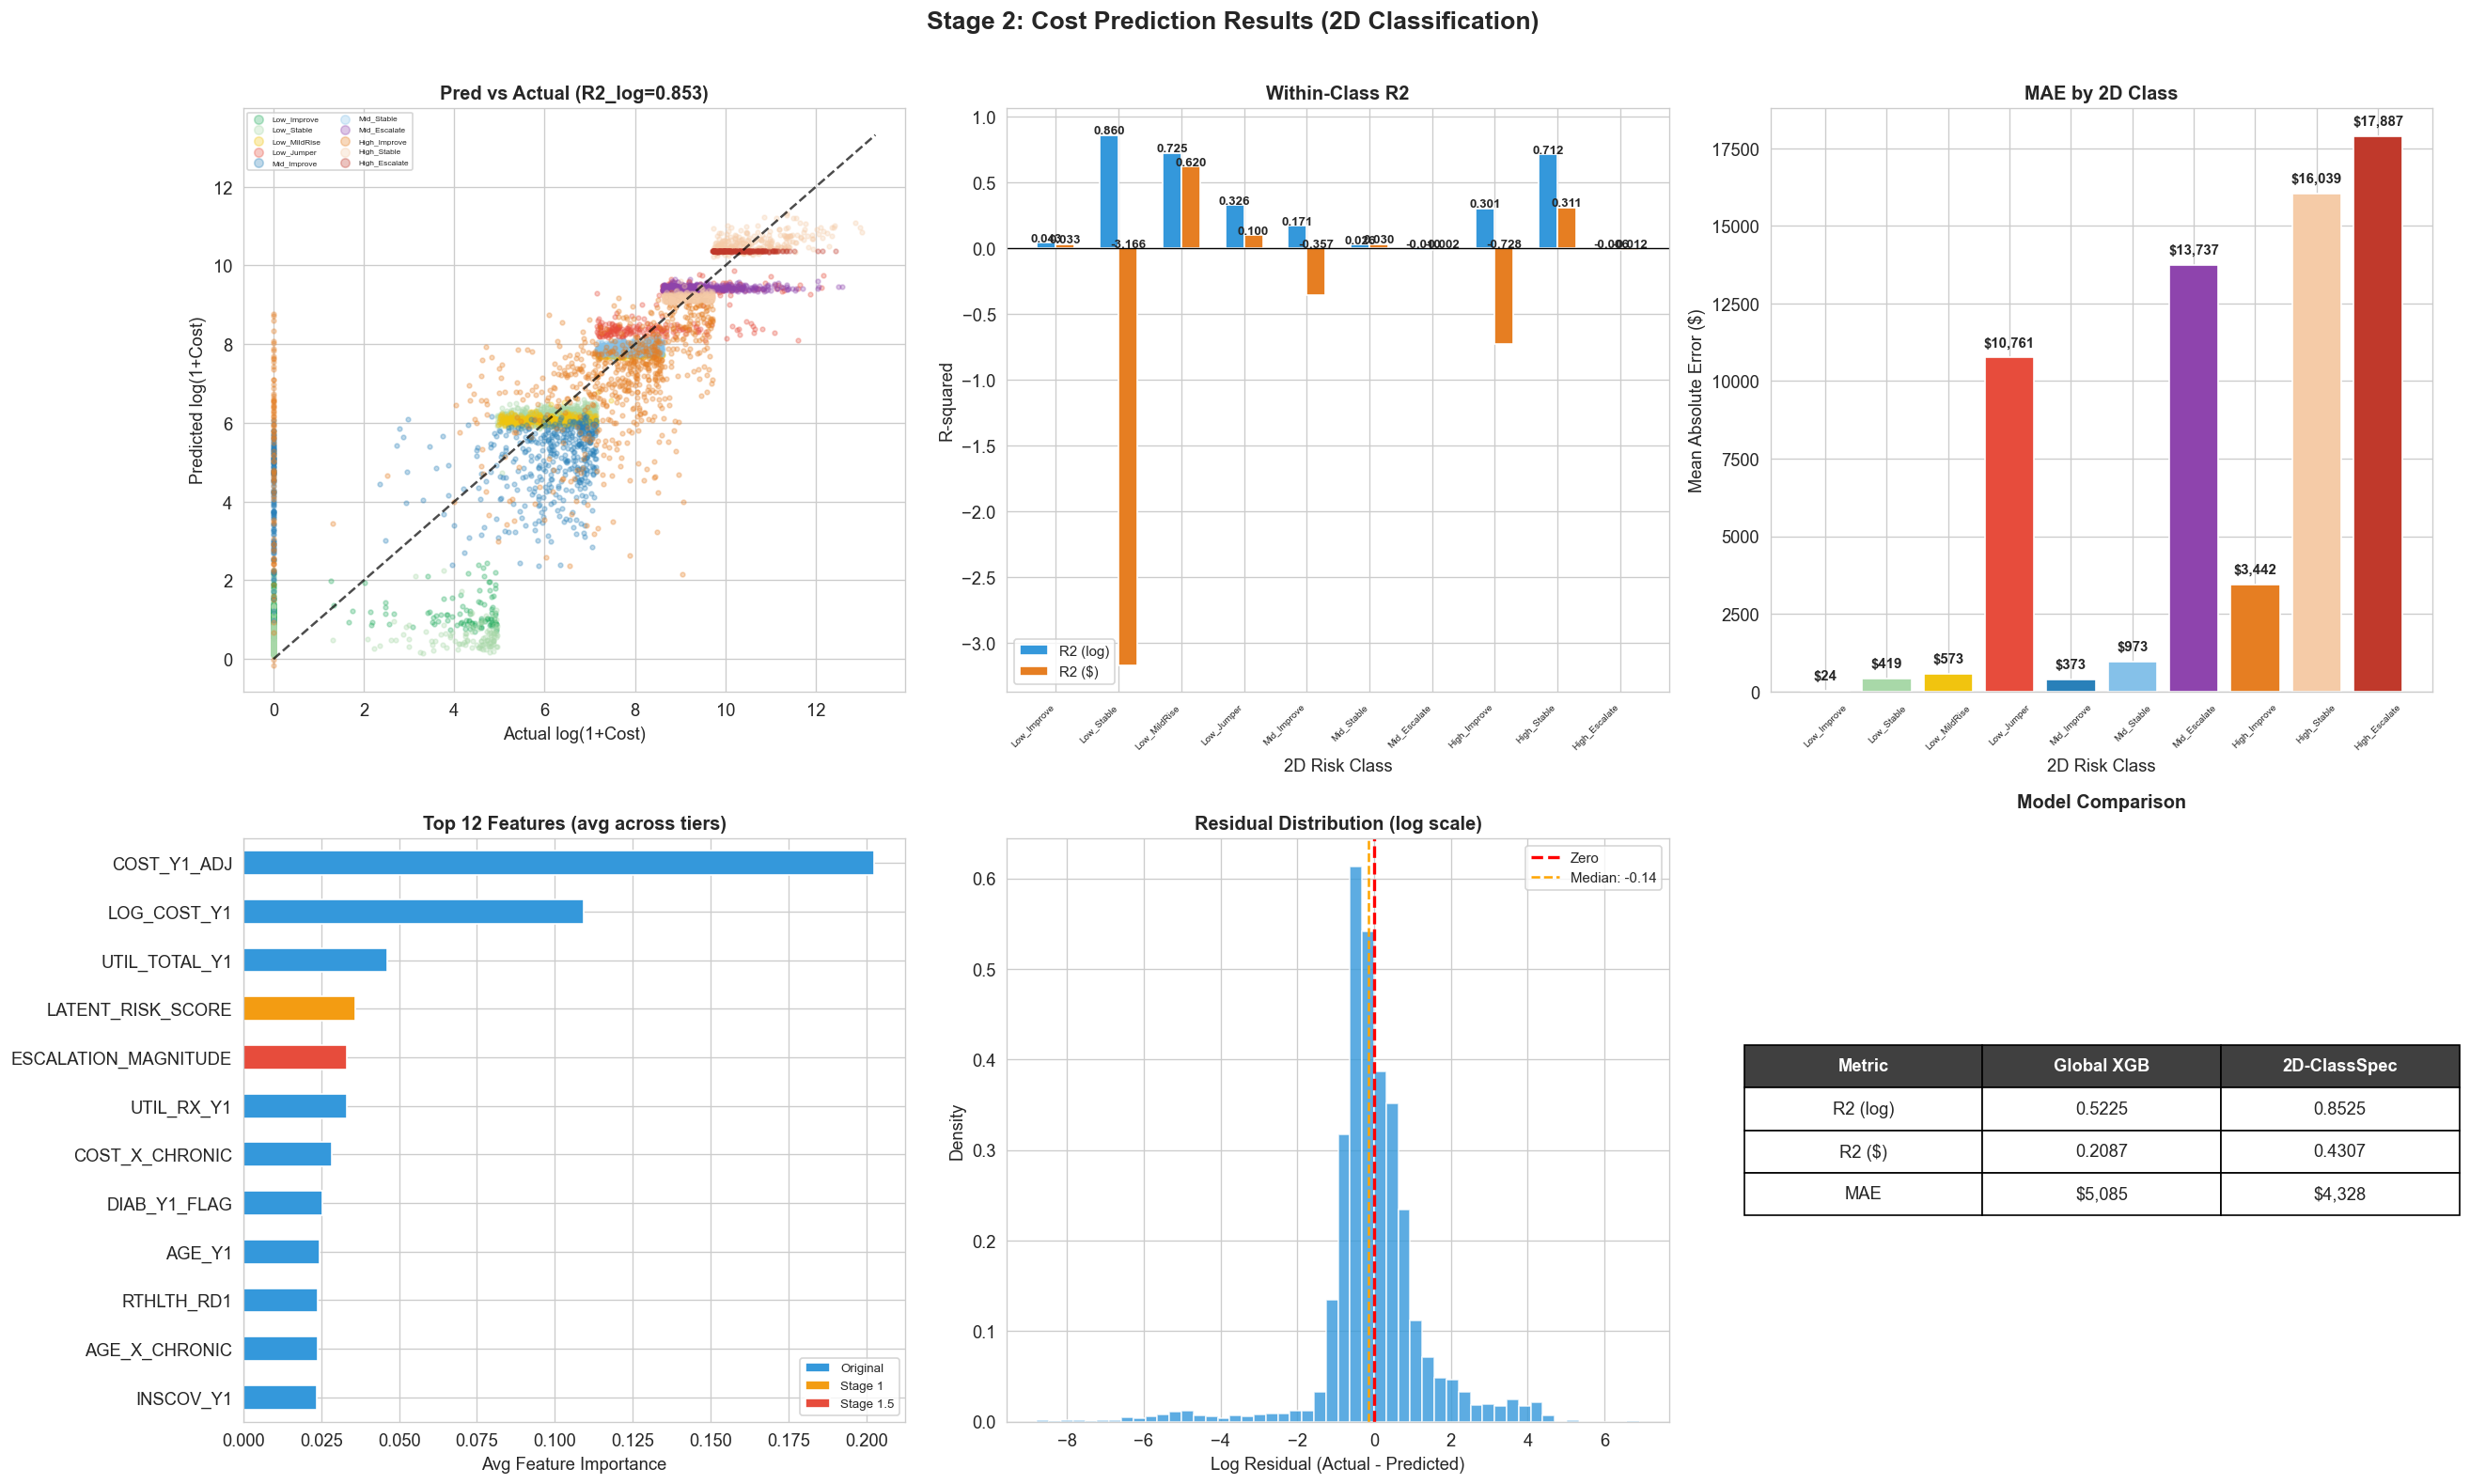

In [40]:
# VISUALIZATION: Stage 2 Results (2D Classification)

fig, axes = plt.subplots(2, 3, figsize=(22, 13))
fig.suptitle('Stage 2: Cost Prediction Results (2D Classification)', fontsize=16, fontweight='bold', y=1.01)

trans_colors = {
    0: '#27ae60', 1: '#a8d8a8', 2: '#f1c40f', 3: '#e74c3c',
    4: '#2980b9', 5: '#85c1e9', 6: '#8e44ad',
    7: '#e67e22', 8: '#f5cba7', 9: '#c0392b',
}

# Panel 1: Pred vs Actual (log scale)
ax1 = axes[0, 0]
for t, tn in tier_names.items():
    m = df_test['RISK_TIER'] == t
    if m.sum() > 0:
        ax1.scatter(y_test_log[m], y_pred_test_log[m], c=trans_colors[t], alpha=0.3, s=8, label=tn)
lim = [0, max(y_test_log.max(), y_pred_test_log.max()) + 0.3]
ax1.plot(lim, lim, 'k--', lw=1.5, alpha=0.7)
ax1.set_xlabel('Actual log(1+Cost)', fontsize=11)
ax1.set_ylabel('Predicted log(1+Cost)', fontsize=11)
r2_overall = r2_score(y_test_log, y_pred_test_log)
ax1.set_title(f'Pred vs Actual (R2_log={r2_overall:.3f})', fontsize=12, fontweight='bold')
ax1.legend(fontsize=5, markerscale=2, ncol=2)

# Panel 2: R2 by Tier (log vs dollar)
ax2 = axes[0, 1]
tier_list = [tn for tn in tier_names.values() if tn in tier_models]
r2_logs = [tier_models[tn]['r2_log'] for tn in tier_list]
r2_dollars = [tier_models[tn]['r2_dollar'] for tn in tier_list]
x = np.arange(len(tier_list))
bars1 = ax2.bar(x - 0.15, r2_logs, 0.3, label='R2 (log)', color='#3498db', edgecolor='white')
bars2 = ax2.bar(x + 0.15, r2_dollars, 0.3, label='R2 ($)', color='#e67e22', edgecolor='white')
for b, v in zip(bars1, r2_logs):
    ax2.text(b.get_x() + b.get_width()/2, max(v, 0) + 0.01, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
for b, v in zip(bars2, r2_dollars):
    ax2.text(b.get_x() + b.get_width()/2, max(v, 0) + 0.01, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
ax2.axhline(y=0, color='black', lw=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(tier_list, fontsize=6, rotation=45, ha='right')
ax2.set_xlabel('2D Risk Class', fontsize=11)
ax2.set_ylabel('R-squared', fontsize=11)
ax2.set_title('Within-Class R2', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

# Panel 3: MAE by Tier
ax3 = axes[0, 2]
maes = [tier_models[tn]['mae'] for tn in tier_list]
tier_color_list = [trans_colors[k] for k, v in tier_names.items() if v in tier_models]
bars = ax3.bar(tier_list, maes, color=tier_color_list, edgecolor='white')
for b, v in zip(bars, maes):
    ax3.text(b.get_x() + b.get_width()/2, v + max(maes)*0.02, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')
ax3.set_xlabel('2D Risk Class', fontsize=11)
ax3.set_ylabel('Mean Absolute Error ($)', fontsize=11)
ax3.set_title('MAE by 2D Class', fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=45, labelsize=6)

# Panel 4: Feature Importance (averaged across tiers)
ax4 = axes[1, 0]
all_imp = pd.DataFrame({tn: info['importance'] for tn, info in tier_models.items()})
avg_imp = all_imp.mean(axis=1).sort_values(ascending=False).head(12)
feat_colors = ['#e74c3c' if f in STAGE1_5_FEATS else '#f39c12' if f == 'LATENT_RISK_SCORE' else '#3498db' for f in avg_imp.index]
avg_imp.plot(kind='barh', ax=ax4, color=feat_colors)
ax4.set_xlabel('Avg Feature Importance', fontsize=11)
ax4.set_title('Top 12 Features (avg across tiers)', fontsize=12, fontweight='bold')
ax4.invert_yaxis()
from matplotlib.patches import Patch
ax4.legend(handles=[Patch(fc='#3498db', label='Original'), Patch(fc='#f39c12', label='Stage 1'), Patch(fc='#e74c3c', label='Stage 1.5')], fontsize=8)

# Panel 5: Residual distribution
ax5 = axes[1, 1]
resids_log = y_test_log - y_pred_test_log
ax5.hist(resids_log, bins=50, color='#3498db', edgecolor='white', alpha=0.8, density=True)
ax5.axvline(x=0, color='red', ls='--', lw=2, label='Zero')
ax5.axvline(x=resids_log.median(), color='orange', ls='--', lw=1.5, label=f'Median: {resids_log.median():.2f}')
ax5.set_xlabel('Log Residual (Actual - Predicted)', fontsize=11)
ax5.set_ylabel('Density', fontsize=11)
ax5.set_title('Residual Distribution (log scale)', fontsize=12, fontweight='bold')
ax5.legend(fontsize=9)

# Panel 6: Summary table
ax6 = axes[1, 2]
ax6.axis('off')
table_data = [
    ['Metric', 'Global XGB', '2D-ClassSpec'],
    ['R2 (log)', f'{r2_global_log:.4f}', f'{r2_tier_log:.4f}'],
    ['R2 ($)', f'{r2_global_dollar:.4f}', f'{r2_tier_dollar:.4f}'],
    ['MAE', f'${mae_global:,.0f}', f'${mae_tier:,.0f}'],
]
table = ax6.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.3, 0.3, 0.3])
table.scale(1.2, 2.0)
for i in range(3):
    table[(0, i)].set_facecolor('#404040')
    table[(0, i)].set_text_props(color='white', fontweight='bold')
ax6.set_title('Model Comparison', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'stage2_results.png', dpi=150, bbox_inches='tight')
plt.show()


### Stage 2 Results

**Reading the results:**
- **R2 (log):** How well the model predicts log(1+cost). Values > 0.5 indicate the model explains more than half of the log-cost variance. This is the primary evaluation metric.
- **R2 ($):** How well predictions track raw dollar amounts. Always lower than R2_log because a few extreme outliers dominate the variance.
- **MAE ($):** Average prediction error in dollars. More interpretable than R2 for clinical use.

**Tier-specific vs Global:**
- If tier-specific R2_log is higher than global, it confirms that separating by tier allows better within-tier prediction.
- The Stable tier typically has the lowest R2 because most patients have near-zero cost — there's little variance to explain.
- The Shock tier MAE is highest in absolute dollars because the cost range is enormous ($10K–$900K).

**How Stage 1.5 helps:** Compare the ablation study below — the R2 gain from adding Stage 1.5 factors quantifies whether intermediate latent variables actually improve prediction beyond original features.


---
## Ablation Study: Value of Latent Factors


ABLATION STUDY
  Original Only                      : R2_log=0.8513, R2_$=0.4105, MAE=$3,784
  + Interactions                     : R2_log=0.8516, R2_$=0.4053, MAE=$3,796
  + LATENT_RISK_SCORE                : R2_log=0.8522, R2_$=0.4108, MAE=$3,790
  + Stage 1.5 Enrichment             : R2_log=0.8522, R2_$=0.4134, MAE=$3,789
  + Full Pipeline (All Features)     : R2_log=0.8525, R2_$=0.4072, MAE=$3,789


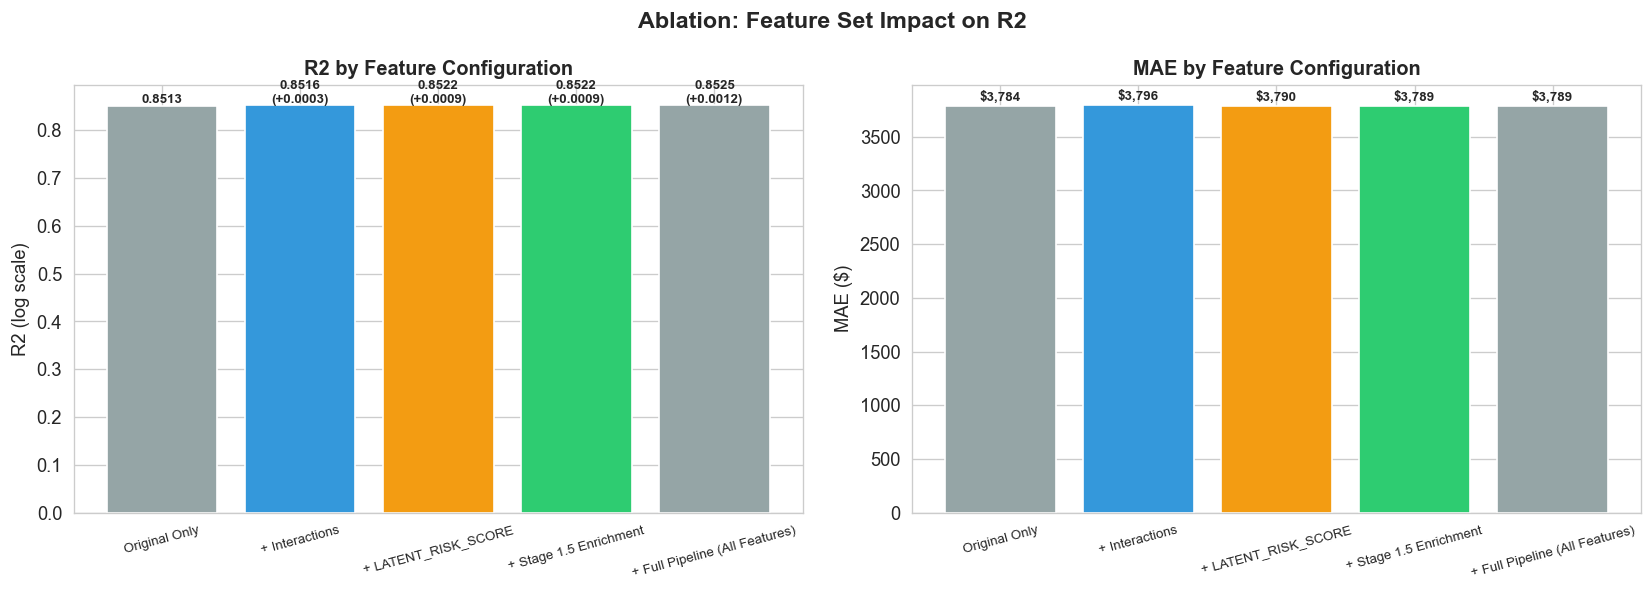

In [41]:
# Ablation: Value of Latent Factors
print('ABLATION STUDY')

def train_tier_ablation(feat_list, name):
    preds_log = np.zeros(len(df_test))
    feats = [f for f in feat_list if f in df.columns]
    for tv in tier_names.keys():
        tr_m = df_train['RISK_TIER'] == tv
        va_m = df_val['RISK_TIER'] == tv
        te_m = df_test['RISK_TIER'] == tv
        if tr_m.sum() < 30 or te_m.sum() < 10:
            continue
        hp = tier_hyperparams.get(tv, tier_hyperparams[1])
        xg = XGBRegressor(n_estimators=hp['n_estimators'], max_depth=hp['max_depth'],
                          learning_rate=0.03, subsample=0.8, colsample_bytree=0.8,
                          reg_alpha=0.5, reg_lambda=hp['reg_lambda'],
                          min_child_weight=hp['min_child_weight'],
                          random_state=42, n_jobs=-1, early_stopping_rounds=50)
        xg.fit(df_train.loc[tr_m, feats].fillna(0), np.log1p(y_train[tr_m]),
               eval_set=[(df_val.loc[va_m, feats].fillna(0), np.log1p(y_val[va_m]))], verbose=False)
        preds_log[te_m.values] = xg.predict(df_test.loc[te_m, feats].fillna(0))
    r2l = r2_score(y_test_log, preds_log)
    r2d = r2_score(y_test, np.clip(np.expm1(preds_log), 0, None))
    mae_v = mean_absolute_error(y_test, np.clip(np.expm1(preds_log), 0, None))
    print(f'  {name:35s}: R2_log={r2l:.4f}, R2_$={r2d:.4f}, MAE=${mae_v:,.0f}')
    return {'Model': name, 'R2_log': r2l, 'R2_dollar': r2d, 'MAE': mae_v, 'N_feats': len(feats)}

results = []
results.append(train_tier_ablation(original_avail, 'Original Only'))
results.append(train_tier_ablation(original_avail + interact_avail, '+ Interactions'))
results.append(train_tier_ablation(original_avail + interact_avail + ['LATENT_RISK_SCORE'], '+ LATENT_RISK_SCORE'))
rx_feats_avail = [f for f in ['RX_DENSITY', 'RX_GAP_RATIO', 'RX_TRAILING_GAP', 'RX_REGULARITY'] if f in df.columns]
results.append(train_tier_ablation(original_avail + interact_avail + stage1_5_avail, '+ Stage 1.5 Enrichment'))
results.append(train_tier_ablation(TIER_FEATS, '+ Full Pipeline (All Features)'))

abl_df = pd.DataFrame(results)
abl_df['R2_log_gain'] = abl_df['R2_log'] - abl_df['R2_log'].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ablation: Feature Set Impact on R2', fontsize=14, fontweight='bold')
colors = ['#95a5a6', '#3498db', '#f39c12', '#2ecc71']

ax1 = axes[0]
bars = ax1.bar(range(len(abl_df)), abl_df['R2_log'], color=colors, edgecolor='white')
for b, v, g in zip(bars, abl_df['R2_log'], abl_df['R2_log_gain']):
    label = f'{v:.4f}' if g == 0 else f'{v:.4f}\n(+{g:.4f})'
    ax1.text(b.get_x()+b.get_width()/2, v+0.005, label, ha='center', fontsize=8, fontweight='bold')
ax1.set_xticks(range(len(abl_df)))
ax1.set_xticklabels(abl_df['Model'], fontsize=8, rotation=15)
ax1.set_ylabel('R2 (log scale)', fontsize=11)
ax1.set_title('R2 by Feature Configuration', fontsize=12, fontweight='bold')

ax2 = axes[1]
bars = ax2.bar(range(len(abl_df)), abl_df['MAE'], color=colors, edgecolor='white')
for b, v in zip(bars, abl_df['MAE']):
    ax2.text(b.get_x()+b.get_width()/2, v+50, f'${v:,.0f}', ha='center', fontsize=8, fontweight='bold')
ax2.set_xticks(range(len(abl_df)))
ax2.set_xticklabels(abl_df['Model'], fontsize=8, rotation=15)
ax2.set_ylabel('MAE ($)', fontsize=11)
ax2.set_title('MAE by Feature Configuration', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'stage2_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
abl_df.to_csv(REPORT_DIR / 'tables' / 'stage2_model_comparison.csv', index=False)


In [42]:
# Save Output
print('Saving...')

df['PREDICTED_COST_Y2'] = 0.0
for tv, tn in tier_names.items():
    mask = df['RISK_TIER'] == tv
    if mask.sum() > 0 and tn in tier_models:
        X = df.loc[mask, TIER_FEATS].fillna(0)
        smear = smearing_factors.get(tn, 1.0)
        df.loc[mask, 'PREDICTED_COST_Y2'] = np.clip(np.expm1(tier_models[tn]['model'].predict(X)) * smear, 0, None)

output_path = Path('../data/processed_v2/model_ready_stage2.parquet')
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(output_path, index=False)
print(f'Saved to {output_path}: {len(df):,} rows, {len(df.columns)} cols')


Saving...
Saved to ../data/processed_v2/model_ready_stage2.parquet: 60,602 rows, 68 cols


---
## Summary

**2D Classification Pipeline (v3):**

- **Stage 1** (5.1): 10-class 2D classification (Y1 cost level × transition direction)
- **Stage 1.5 kept:** ENGAGEMENT_SCORE (direct), ESCALATION_MAGNITUDE (regression on DELTA_BIN), Raw Rx features (4 vars)
- **Stage 1.5 removed:** PROB_CRISIS_MODE, ESCALATION_SCORE, HAZARD_DISCONTINUE (all redundant)
- **Stage 2:** 2D class-specific XGBoost on log(1+cost) target, with LATENT_RISK_SCORE as a feature within each class
- **Evaluation:** R2 reported on BOTH log and dollar scales
